# Analysis script for Sensory Gating Effect in Visual Cortex during Change Detection Tasks
Man-Shan Chang, Andre Pfrommer, Martin Gruber

# Data loading and Preprocessing
The preprocessing consists of extracting spike activity via oasis, low-pass filtering of running traces and identification of running times

In [25]:
from utils.utils import *
import matplotlib.pyplot as plt

#### Data Loading

In [26]:
data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes']

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


#### Spike extraction from calcium traces via OASIS

In [27]:
data = spike_inference(data)

To visually assess the oasis fit, we can plot it below

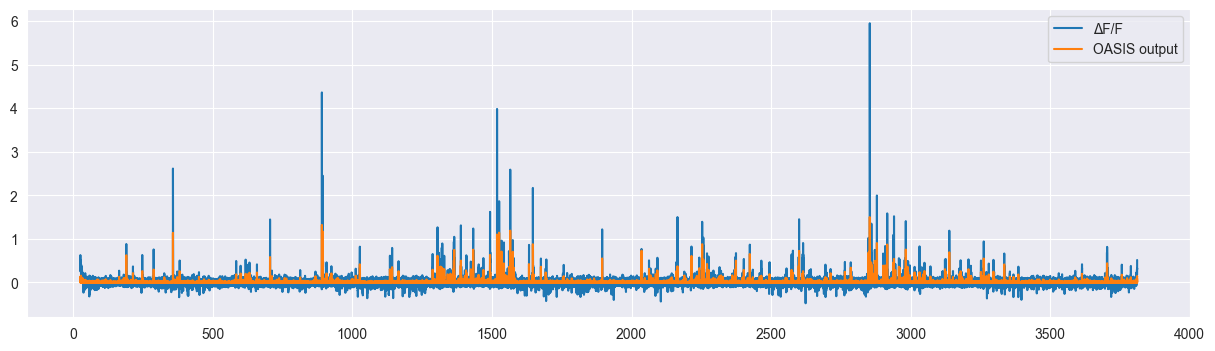

In [28]:
plot_oasis_result(data, "B")

#### Running speed preprocessing


In [29]:
data = preprocess_running_speed(data, high=5, order=3, clip_speed=True, running_threshold=5.0)

To visually assess the result of filtering and running phase extraction, we can plot the running speed over the time course of the whole session and compare it with the filtered version

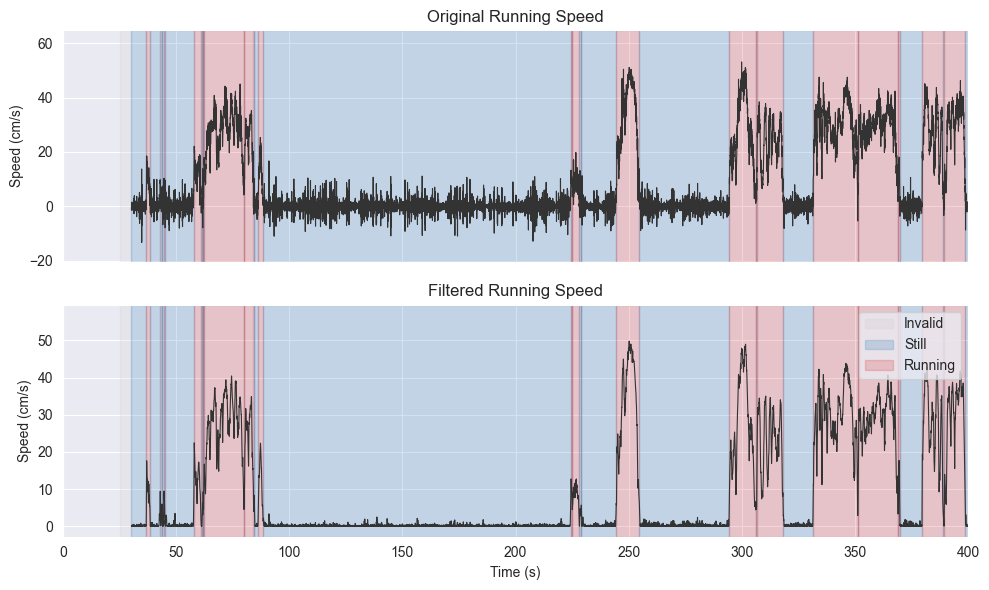

In [30]:
fig, axs = plot_running_speed(data, session="B", t=(0, 400))
plt.show()

# Exploratory analysis

In this section, the main goal is to observe if the neural acitivity decrease when there is a movement.

We start with Raster plot with stimulus onset and pair with running speed for the whole session to see the overall activity.

Then we compare the neural activity within stimulus onset between moving and non-moving to check if there is difference between different locomotion.

## 1. raster plots to see how neural respond in each session

### Raster plot with neural activity


In [31]:
for session in ["A", "B", "C"]:
    t = data["sessions"][session]["t"]
    print(f"Session {session}: {t[0]:.1f}s ~ {t[-1]:.1f}s (overall length {t[-1] - t[0]:.1f} sec)")

Session A: 9.7s ~ 3849.6s (overall length 3839.9 sec)
Session B: 25.4s ~ 3811.3s (overall length 3785.9 sec)
Session C: 7.7s ~ 3523.6s (overall length 3515.8 sec)


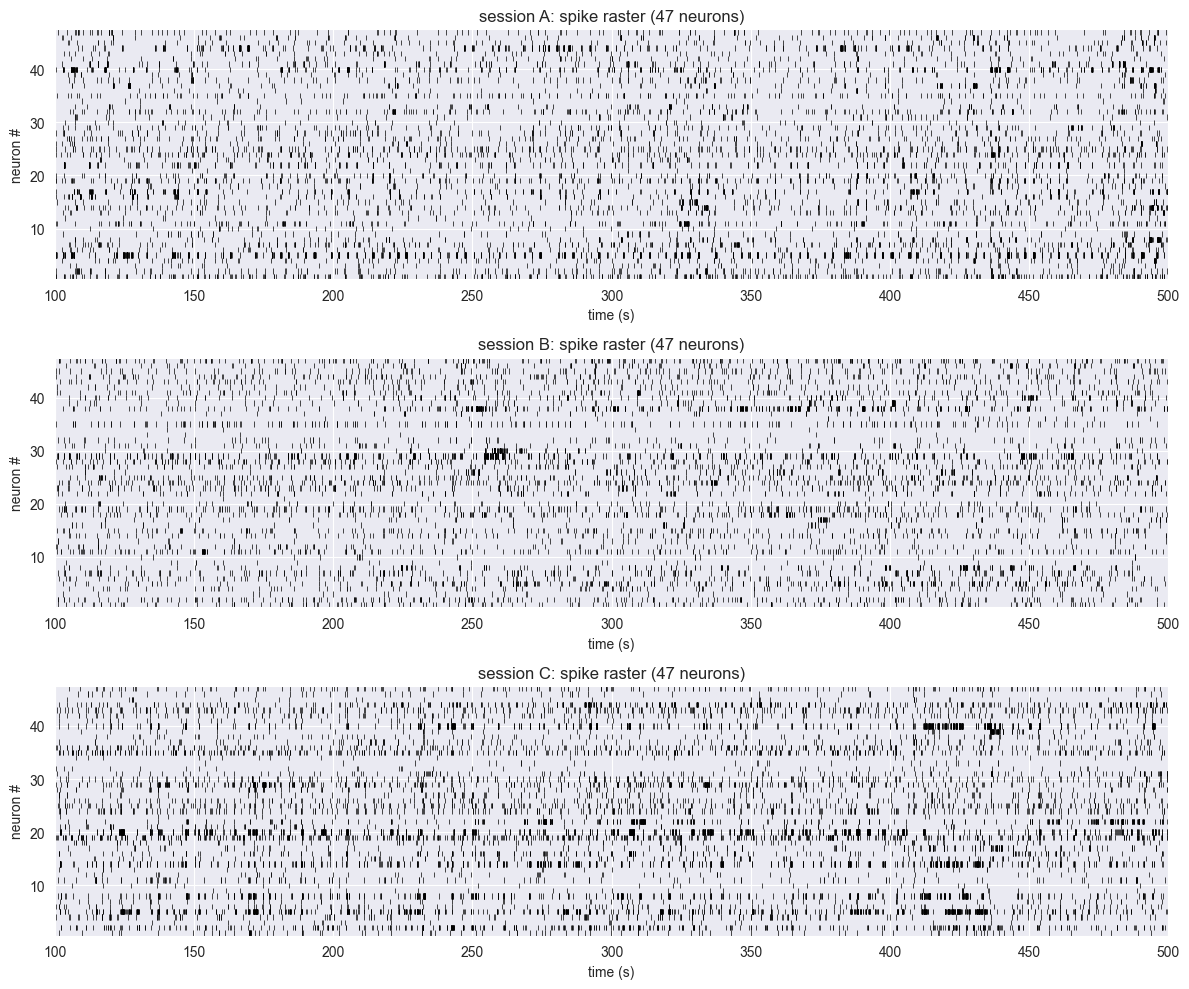

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(100, 500))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(100, 500))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(100, 500))

plt.tight_layout()
plt.show()

### Raster plot paired with running speed

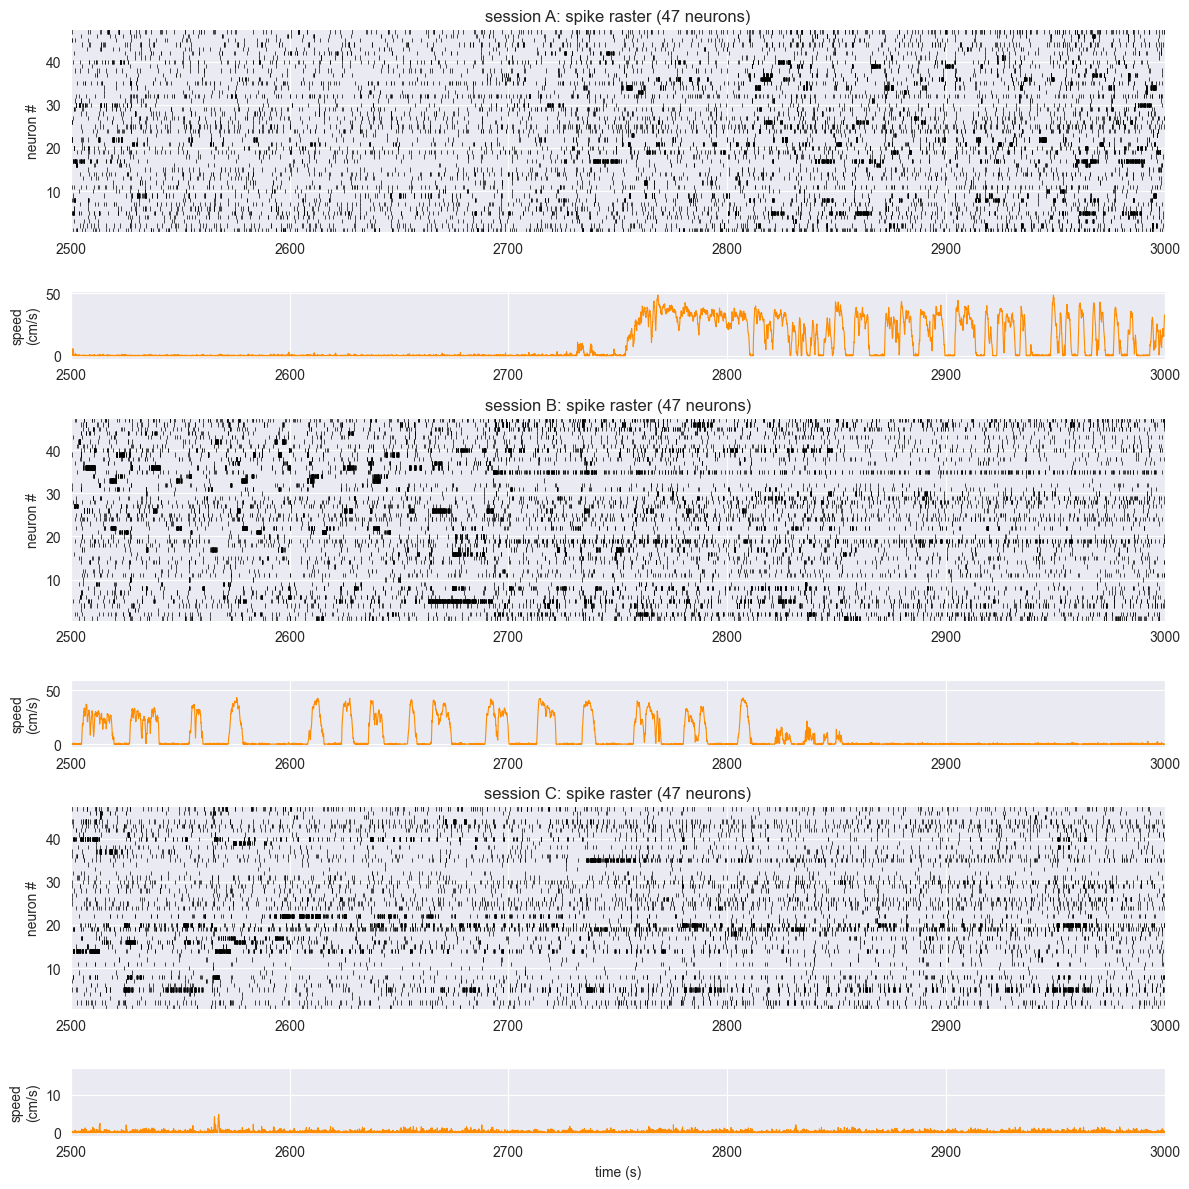

In [33]:
fig, axes = plot_spike_raster_with_running_all_sessions(
    data, sessions=["A", "B", "C"], threshold=0.02, xlim=(2500, 3000)
)
plt.show()

### Raster plot with running and stimulus timing

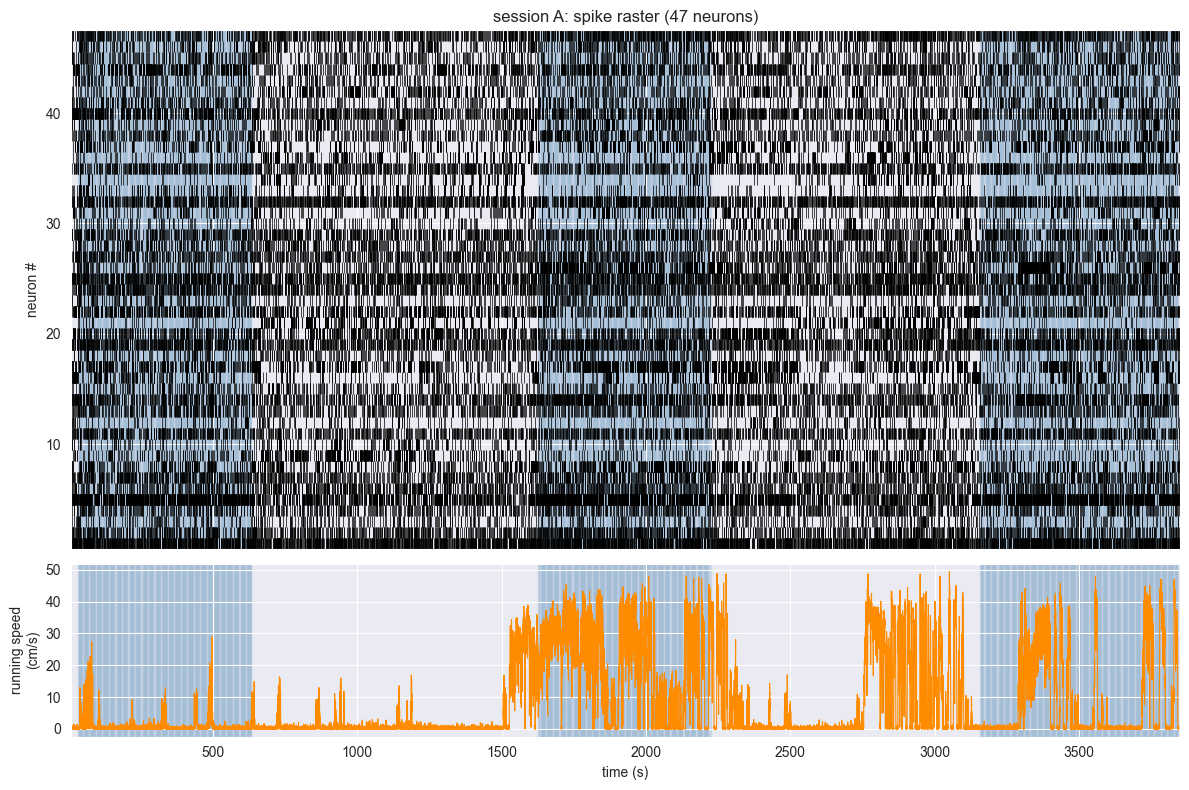

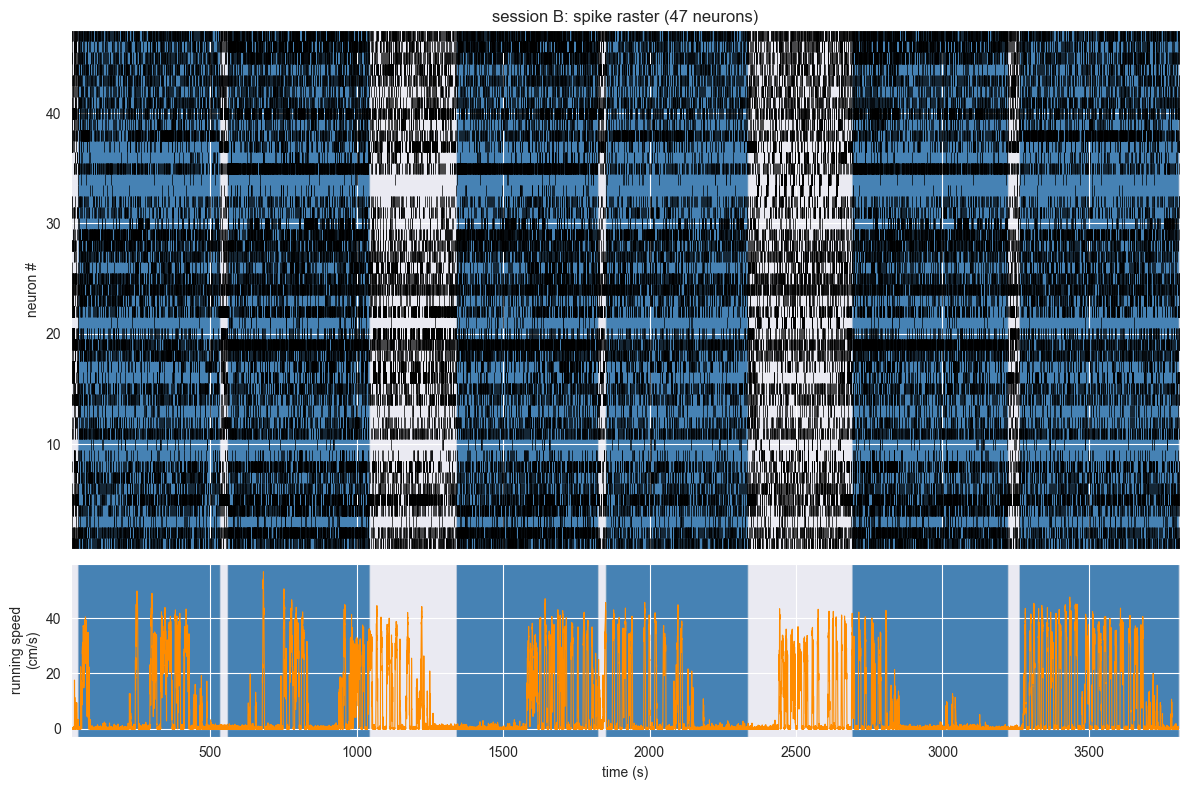

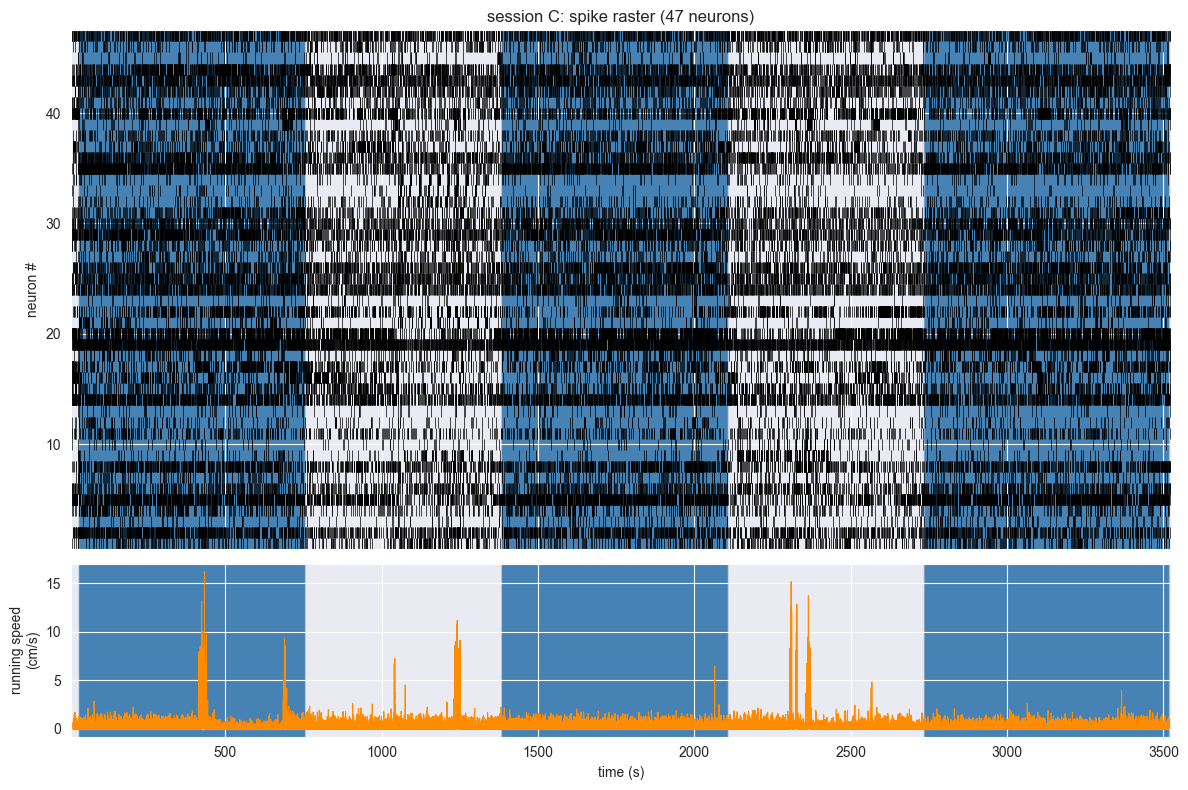

In [34]:
# Session A
fig, (ax_raster, ax_speed) = plot_spike_raster_with_running(
    data, session="A", threshold=0.02, xlim=(9, 3849)
)
plt.show()

# Session B
fig, (ax_raster, ax_speed) = plot_spike_raster_with_running(
    data, session="B", threshold=0.02, xlim=(25, 3811)
)
plt.show()

# Session C
fig, (ax_raster, ax_speed) = plot_spike_raster_with_running(
    data, session="C", threshold=0.02, xlim=(7, 3523)
)
plt.show()

### Using neuron 8, 15, 25, 36 as example neuron

Found this four neurons have different property toward movement

Neuron 8: Only responsive to drifting grating. Show higher activity when moving\
Neuron 15: Only responsive to drifting grating. Show higher activity when not-moving\
Neuron 25: Response to both drifting grating and natural scene. Show higher response when moving\
Neuron 36: Response to both drifting grating and sparse stimuli.

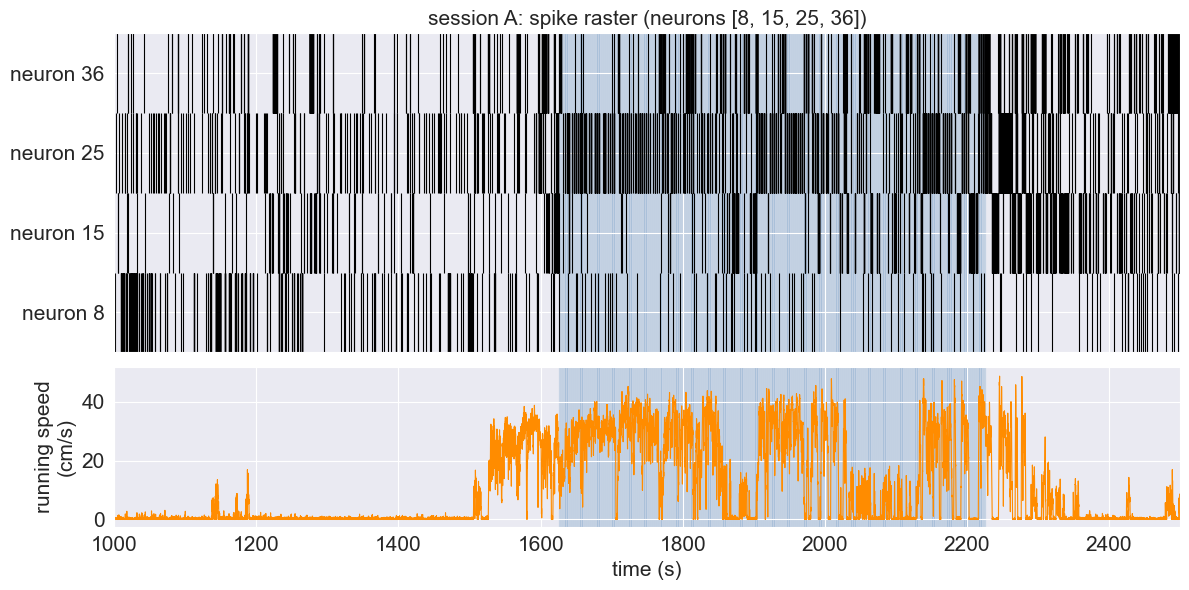

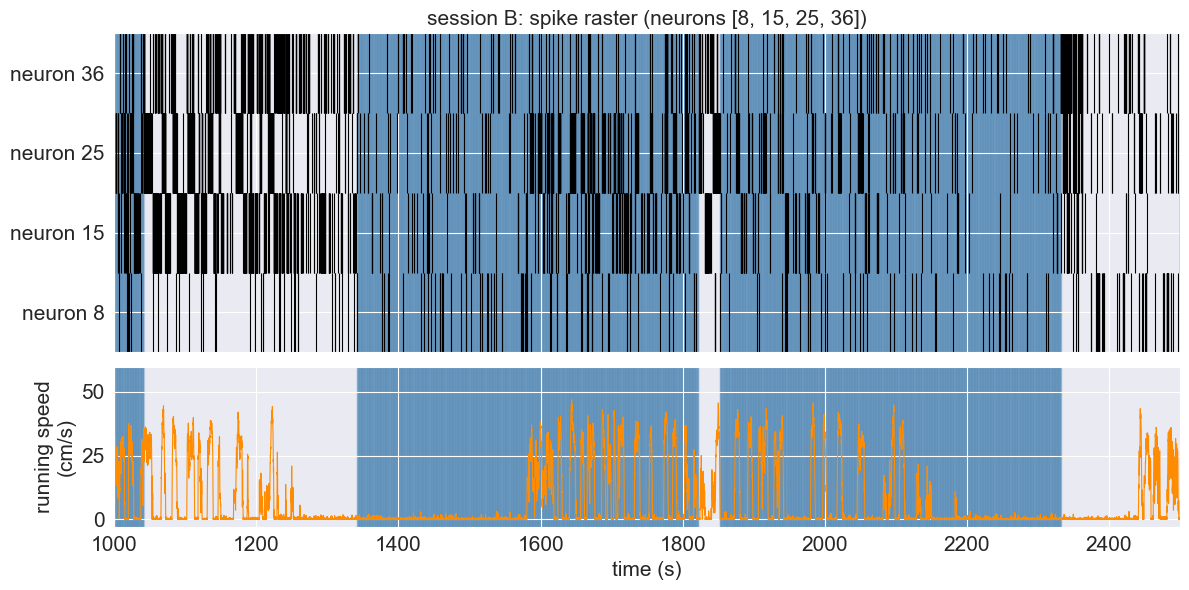

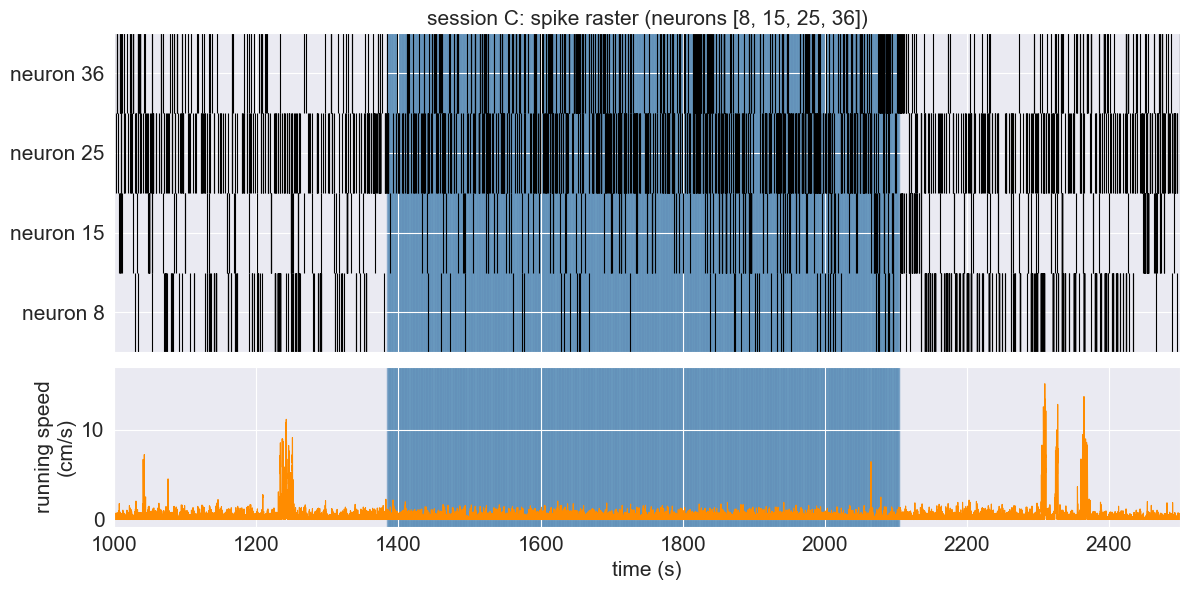

In [35]:
# Session A
fig, (ax_raster, ax_speed) = plot_spike_raster_subset_with_running(
    data, session="A", cell_ids=[8, 15, 25, 36], threshold=0.02, xlim=(1000, 2500)
)
plt.show()

# Session B
fig, (ax_raster, ax_speed) = plot_spike_raster_subset_with_running(
    data, session="B", cell_ids=[8, 15, 25, 36], threshold=0.02, xlim=(1000, 2500)
)
plt.show()

# Session C
fig, (ax_raster, ax_speed) = plot_spike_raster_subset_with_running(
    data, session="C", cell_ids=[8, 15, 25, 36], threshold=0.02, xlim=(1000, 2500)
)
plt.show()

## 2. Compare the neural activity within stimulus onset between moving and non-moving

In [36]:
cell_ids = [25, 36]

df = compare_neuron_activity_by_movement(
    data, session="A", stim_name="drifting_gratings", cell_ids=cell_ids
)

print(df.groupby(["cell", "movement_state"])["sum_spikes"].describe())

                     count      mean       std  min       25%       50%  \
cell movement_state                                                       
25   moving          244.0  0.107913  0.414003  0.0  0.000000  0.000000   
     stationary      384.0  0.023251  0.037488  0.0  0.003607  0.016577   
36   moving          244.0  0.147915  0.632499  0.0  0.000000  0.004052   
     stationary      384.0  0.115439  0.733181  0.0  0.000000  0.003884   

                          75%        max  
cell movement_state                       
25   moving          0.031777   3.162265  
     stationary      0.031663   0.532258  
36   moving          0.020189   7.412800  
     stationary      0.020607  11.401155  


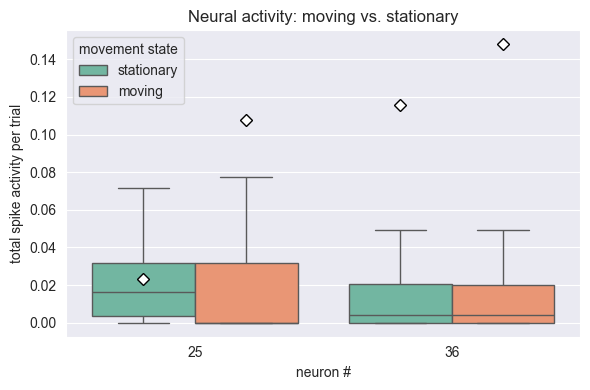

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_neuron_activity_by_movement(df, ax=ax)
plt.tight_layout()
plt.show()

### Here we scan all the neurons trying to see who show interesting property

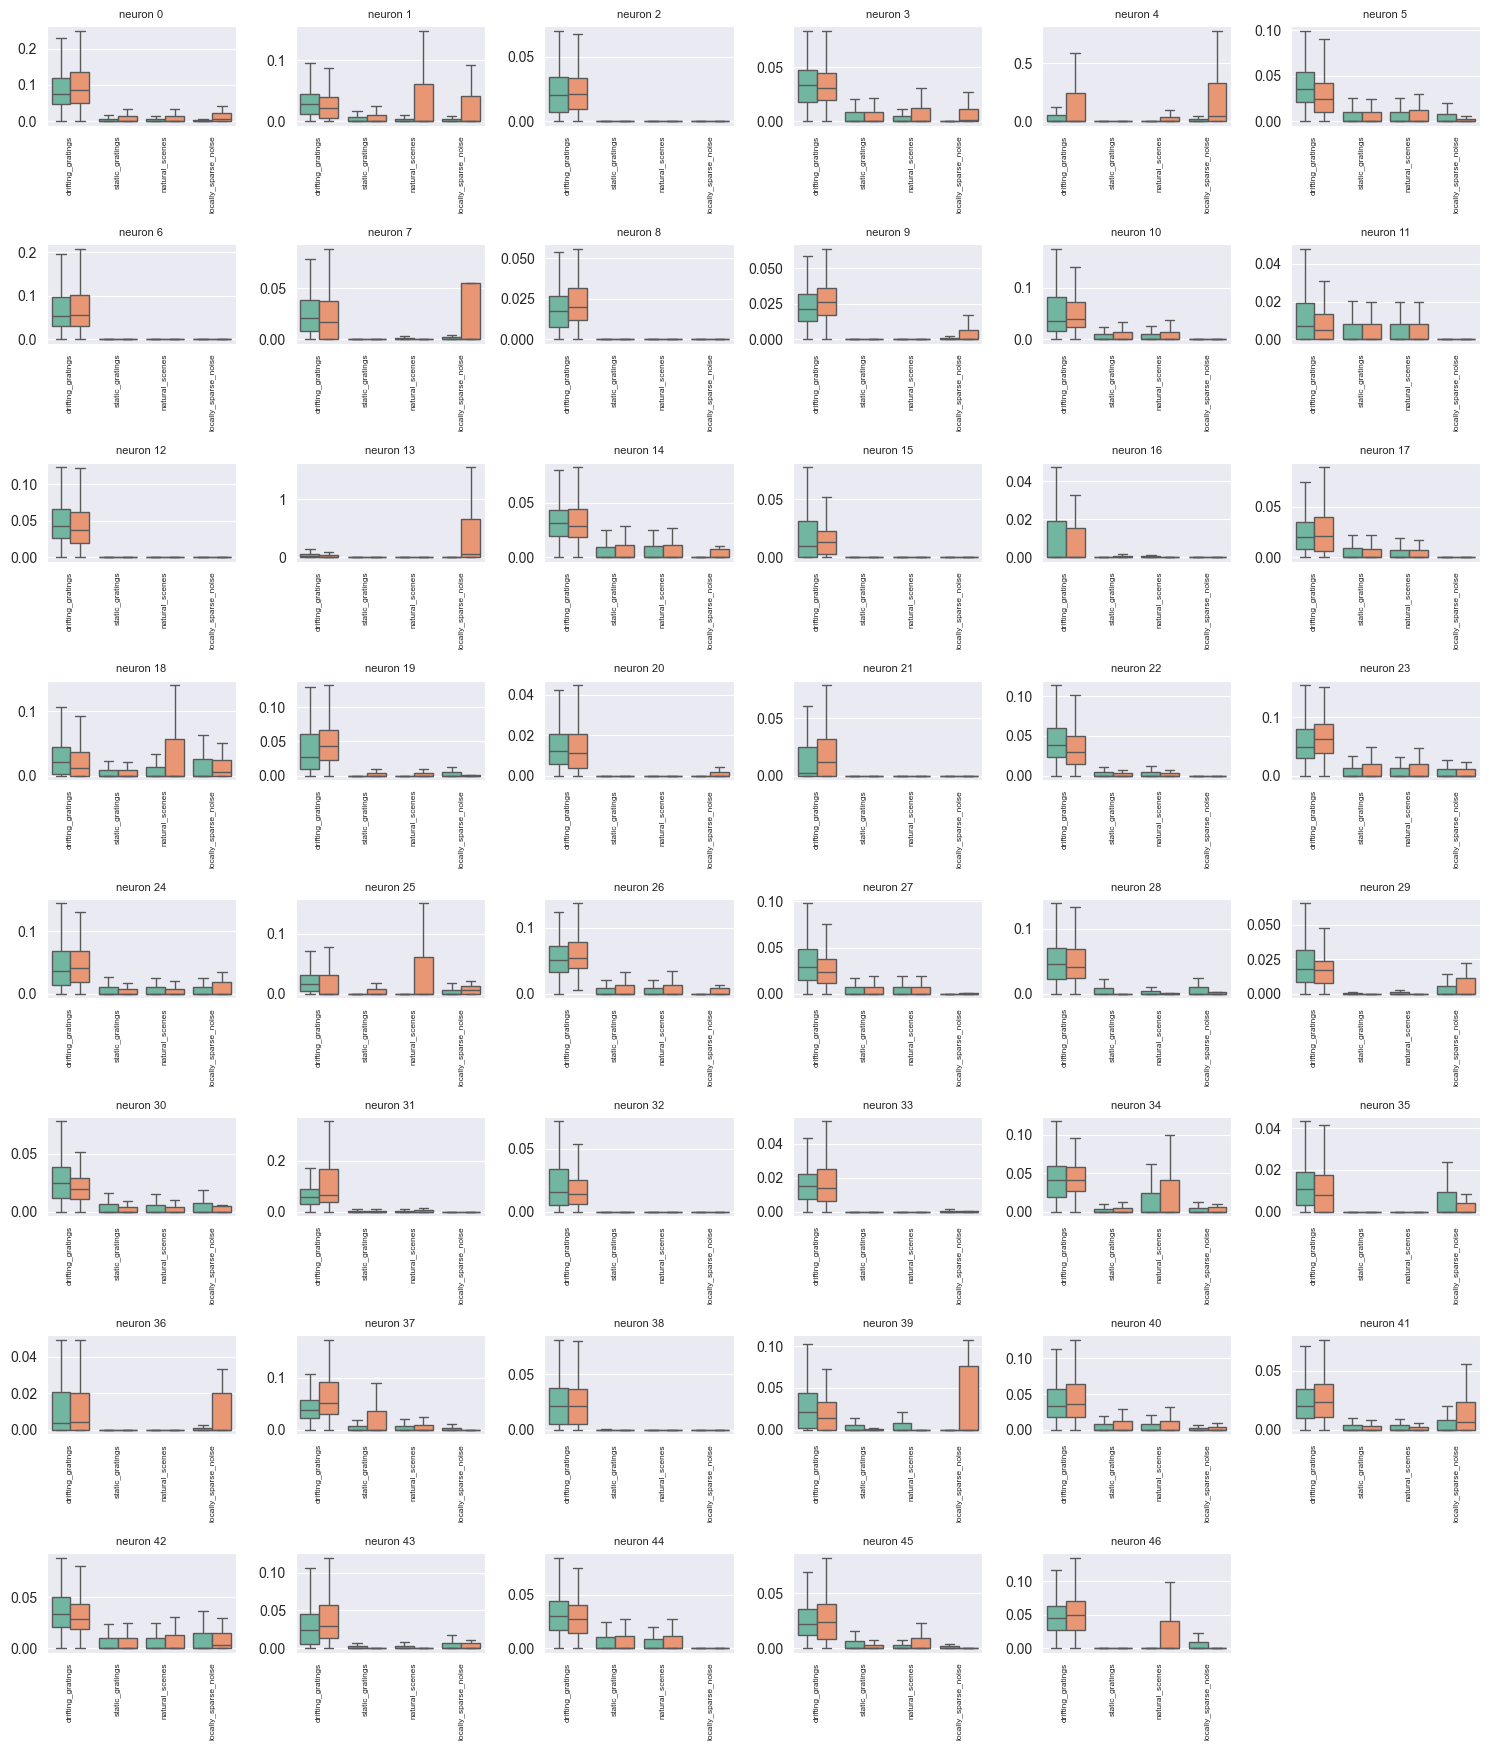

In [38]:
fig, axes = plot_all_neurons_movement_grid(data)
plt.show()

### Choose the neurons of interest

In [39]:
df_movement = compare_activity_by_movement_all_stimuli(data, cell_ids=[8, 15, 25, 36])

# print(df_movement.groupby(["neuron", "stimulus", "movement_state"])["sum_spikes"].describe())

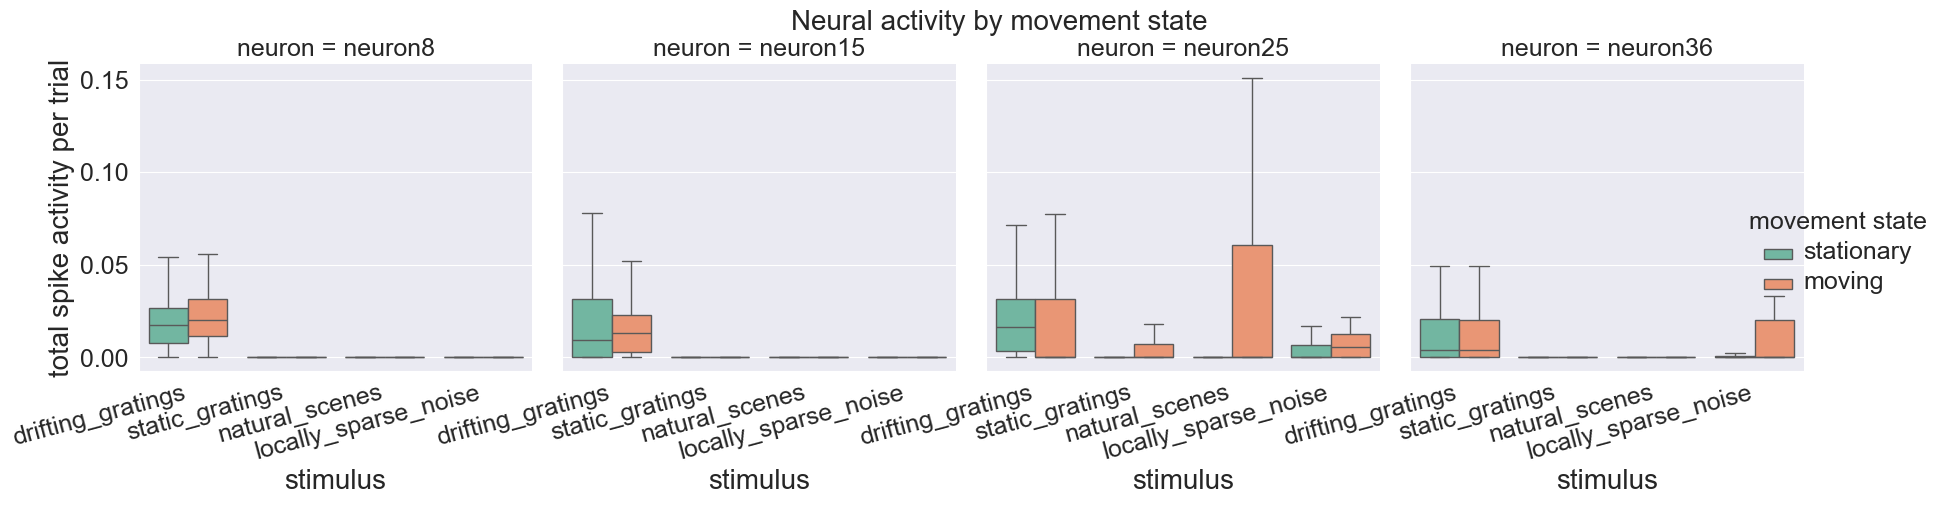

In [40]:
plot_activity_by_movement_per_cell(df_movement)
plt.show()

## Intermediate results

We also tried different kind of comparison.
1. Compare if there is difference of running speed within trials across different stimulus. We expect to see mice may have more movement when seeing the natural scene. Yet, there is no obvious difference.

2. Compare the running speed between neutral and aversive stimulus. We expect to see within session B, mice may be more reponsive to the aversive scences. Yet, we also didn't see any obvious difference

3. This one is out of curious which stimuli would induce the visual cortex response the most. The result showed that the drifting grating is the most and followed by the natural scene.

## Extract the running speed across different stimulus
Not in the poster

Under this section, to see if there is difference of running speed between different stimulus, I seperated the stimulus into four different kinds:
drifting_gratings, static_gratings, natural_scenes, locally_sparse_noise
and further extract the running speed within the stimulus onset across different stimulus

### Compare the running speed across different stimulus
Here is the plotting session for running speed across the four stimulus

C:\Users\grube\OneDrive\Studium\Semester4\Neural Data Science\Project\neural_data_science_project\utils\utils.py:675: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="speed", ax=ax,


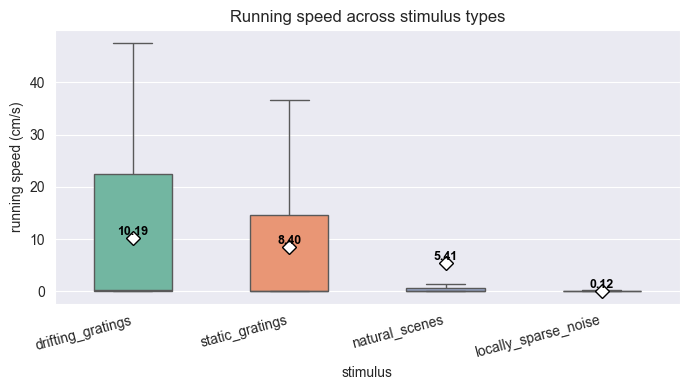

In [41]:

data = preprocess_running_speed(data)

stimulus_speed = get_running_speed_by_stimulus(data, filtered=True)

fig, ax = plt.subplots(figsize=(7, 4))
plot_speed_by_stimulus(stimulus_speed, ax=ax)
plt.tight_layout()
plt.show()

## Visualize natural scence and further comparison

Not in the poster

This section aims to see if mice would respond differently (movement and neural activity) with "aversive" and "neutral" natural scenes. (No rewarding scene since there is no obvious reward for mice)

### Summary: Not really see the difference both in neural activity and running speed between aversive or neutral scenes


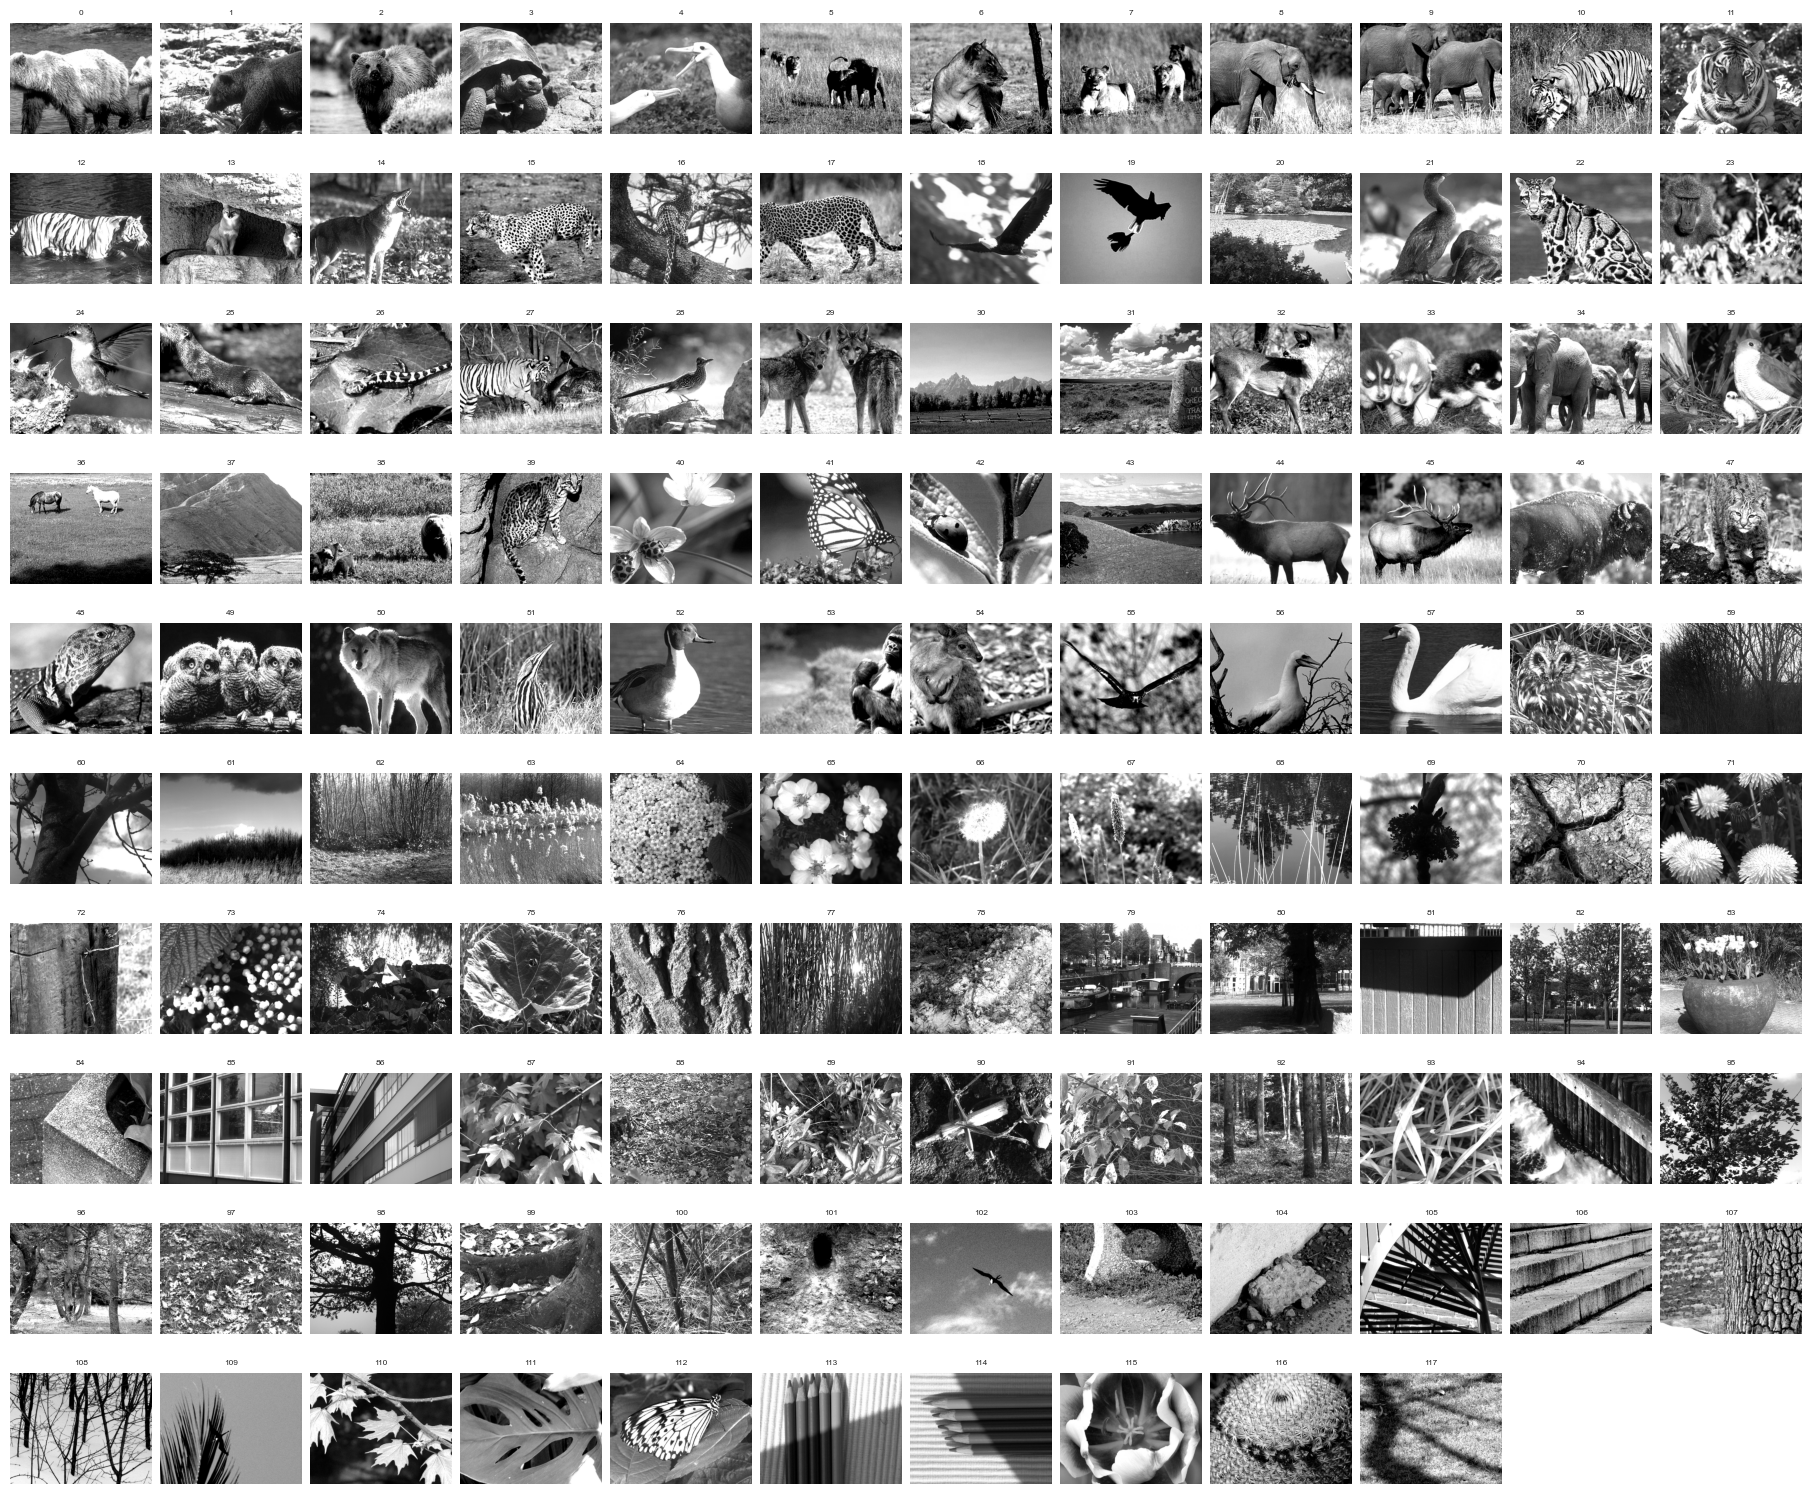

In [42]:
show_all_natural_scenes(data)

In [43]:
# Categorized the pictures into aversive and neutral
aversive_frames = [
    0, 1, 2,      # bears
    4,            # Bird
    6, 7,         # lions
    8, 9,         # elephant
    10, 11, 12,   # tigers close-up
    13, 14,       # coyote howling
    15, 16,       # cheetah
    17,           # leopard
    18,           # eagle
    19,           # birds fighting
    21,           # bird
    22,           # leopard/jaguar close-up
    23,           # monkey
    25,           # Otter
    27,           # tiger
    28,           # bird
    29,           # coyotes
    34,           # elephants
    35,           # bird
    39,           # leopard camouflaged
    47,           # bobcat
    49,           # bird
    50,           # wolf/coyote
    51,52,        # bird
    55,56,        # hawk flying
    58,           # owl
    102,          # bird
]

frame_to_category = {i: "aversive" for i in aversive_frames}
for i in range(118):
    if i not in frame_to_category:
        frame_to_category[i] = "neutral"
trial_df = get_speed_per_trial(data, session="B", stim_name="natural_scenes",
                                 frame_to_category=frame_to_category)

print(trial_df.head())

   frame  start    end  mean_speed  category
0     35  16096  16103    0.133995  aversive
1     49  16104  16111    0.103649  aversive
2    107  16111  16118    0.052961   neutral
3     53  16119  16126    0.018418   neutral
4    110  16126  16133    0.000000   neutral


C:\Users\grube\OneDrive\Studium\Semester4\Neural Data Science\Project\neural_data_science_project\utils\utils.py:787: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trial_df, x="category", y="mean_speed", ax=ax,


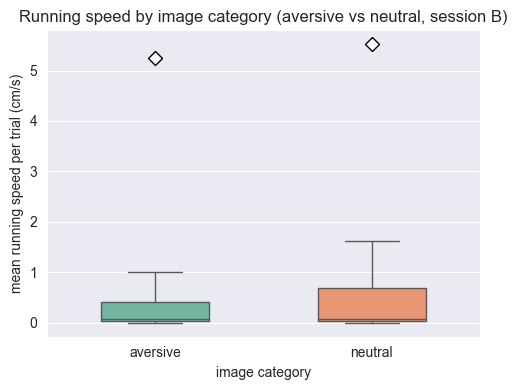

In [44]:
plot_speed_by_category(trial_df)
plt.tight_layout()
plt.show()

           count      mean       std       min       25%       50%       75%  \
category                                                                       
aversive  1850.0  1.282755  1.239957  0.000000  0.386504  0.891998  1.760151   
neutral   4050.0  1.190992  1.206044  0.003033  0.337542  0.788963  1.645466   

               max  
category            
aversive  8.176607  
neutral   9.663793  


C:\Users\grube\AppData\Local\Temp\ipykernel_16840\2547138714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=neural_df, x="category", y="sum_spikes", ax=ax,


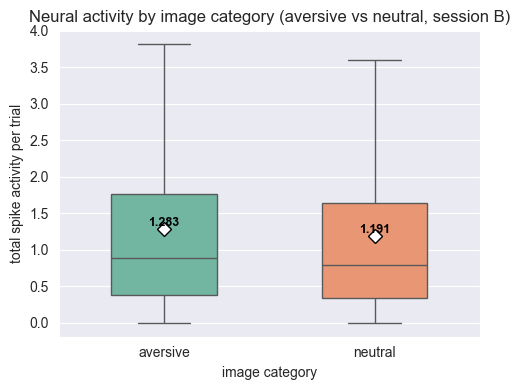

In [45]:
neural_df = get_neural_activity_per_trial(data, session="B", stim_name="natural_scenes",
                                            frame_to_category=frame_to_category)

print(neural_df.groupby("category")["sum_spikes"].describe())

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=neural_df, x="category", y="sum_spikes", ax=ax,
            showfliers=False, width=0.5, palette="Set2",
            showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white",
                       "markeredgecolor": "black", "markersize": 7})

# Annotate each box with its mean value as text
categories = neural_df["category"].unique()
for i, cat in enumerate(categories):
    mean_val = neural_df[neural_df["category"] == cat]["sum_spikes"].mean()
    ax.text(i, mean_val, f"{mean_val:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="black")

ax.set_xlabel("image category")
ax.set_ylabel("total spike activity per trial")
ax.set_title("Neural activity by image category (aversive vs neutral, session B)")
plt.tight_layout()
plt.show()

## Overall spike activity comparison across different stimulus

### Summary: Overall neurons showed stronger sctivity toward drifting grating. The second one would be natural scenes

C:\Users\grube\OneDrive\Studium\Semester4\Neural Data Science\Project\neural_data_science_project\utils\utils.py:860: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="sum_spikes", ax=ax,


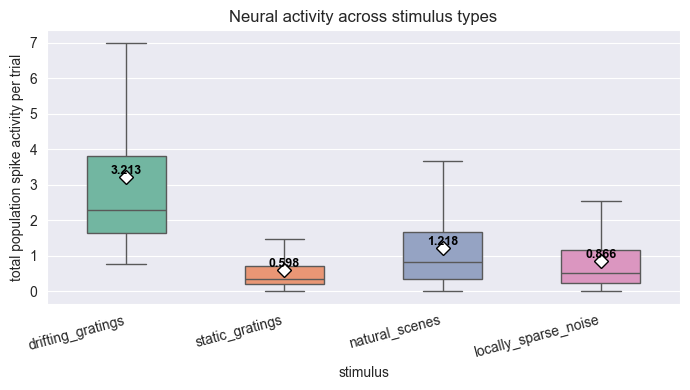

In [46]:
stimulus_activity = get_neural_activity_by_stimulus(data)

fig, ax = plt.subplots(figsize=(7, 4))
plot_activity_by_stimulus(stimulus_activity, ax=ax)
plt.tight_layout()
plt.show()

# Correlational and Onset Analysis
This section examines if, how and where running speed or running onsets correlate with neural activity in terms of extracted spikes via oasis

## Running speed - Spike Correlations

#### Compute Running - Spike Correlations
This analysis requires three main steps:
1) extracting the phases in which no stimulus was shown, as we don't want to capture stimulus-driven effects influence either on neural activity or running speed (e.g. predator image)
2) Downsampling the (continuous) data to increase the strength of possible effects
3) Applying statistical methods to identify possible modulators effects of running. For this, we look at pearson (and spearman) correlations and the explained variance of a simple linear regression

The method 'perform_running_modulation_analysis' performs all three steps for each neuron of each session.

Note: session C contains substantially less spontaneous data (and later on onset data) compared to session A and B which is why the interpretation will mainly focus on the results of sessions A and B, although sessions Cs results are included.

In [47]:
results, binned_data = perform_running_modulation_analysis(data)
for name, session in data["sessions"].items():
    print(name)
    print(results[name].describe())

C
          neuron  pearson_r  spearman_rho      slope  intercept            r2
count  47.000000  47.000000     47.000000  47.000000  47.000000  4.700000e+01
mean   23.000000   0.008237      0.002745   0.000742   0.002212  8.384902e-04
std    13.711309   0.028061      0.013918   0.003555   0.003613  2.743247e-03
min     0.000000  -0.016839     -0.023363  -0.003839   0.000117  6.253664e-09
25%    11.500000  -0.007348     -0.008711  -0.000085   0.000319  1.536244e-05
50%    23.000000   0.000079      0.001043   0.000004   0.000927  7.488297e-05
75%    34.500000   0.010463      0.012447   0.000211   0.002114  2.098401e-04
max    46.000000   0.129414      0.035166   0.020012   0.019288  1.674794e-02
B
          neuron  pearson_r  spearman_rho      slope  intercept            r2
count  47.000000  47.000000     47.000000  47.000000  47.000000  4.700000e+01
mean   23.000000  -0.011030     -0.001643  -0.000060   0.004116  7.746778e-03
std    13.711309   0.088266      0.077113   0.000396   0.009

As the preview of the data already suggests, there is high variablity between neurons with no substantial mean correlation over all neurons (between -.001 and +.002) but also neurons that show mild negative correlations and some that show strong positive correlations (between -0.3 to + 0.63; session B). The next block will investigate this distribution and the individual neuron's correlations and mean running speed modulations further.

### Running correlation plots

First we can look at the distribution of (pearson) correlations, to see what drives the variability. For this, we can visualize the data
1) as histogram and
2) with the neurons sorted by correlation strength

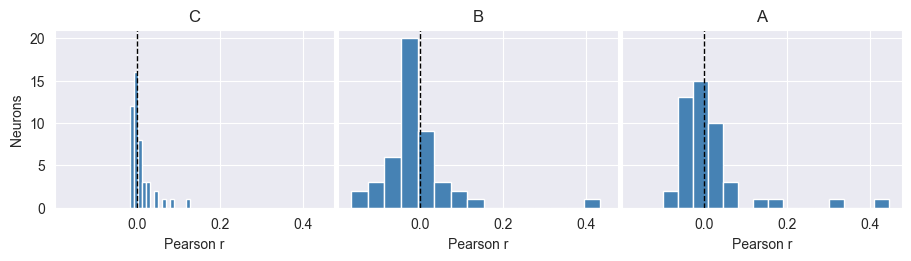

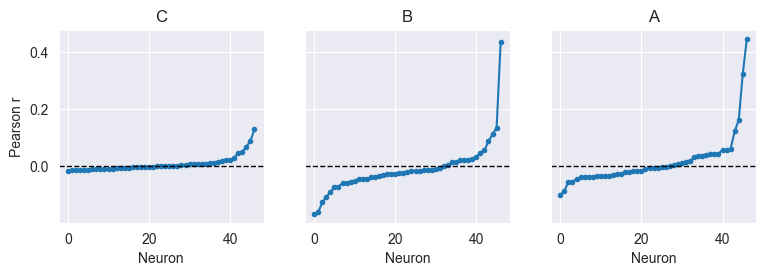

In [48]:
plot_correlation_histograms(results)
plot_running_correlations(results)

We can see, that most neuron's activity is not/barely positively or negatively correlated with running speed, which results in a distribution around 0. However, there is a small number of strong outliers, most notably is neuron 25 (the one with the highest positive correlation of >.63 in session A and B)

To investigate the speed modulation in general population further, we can plot the result of the linear regression (red curve) and the mean activity for different running speeds (blue curve) for all neurons.

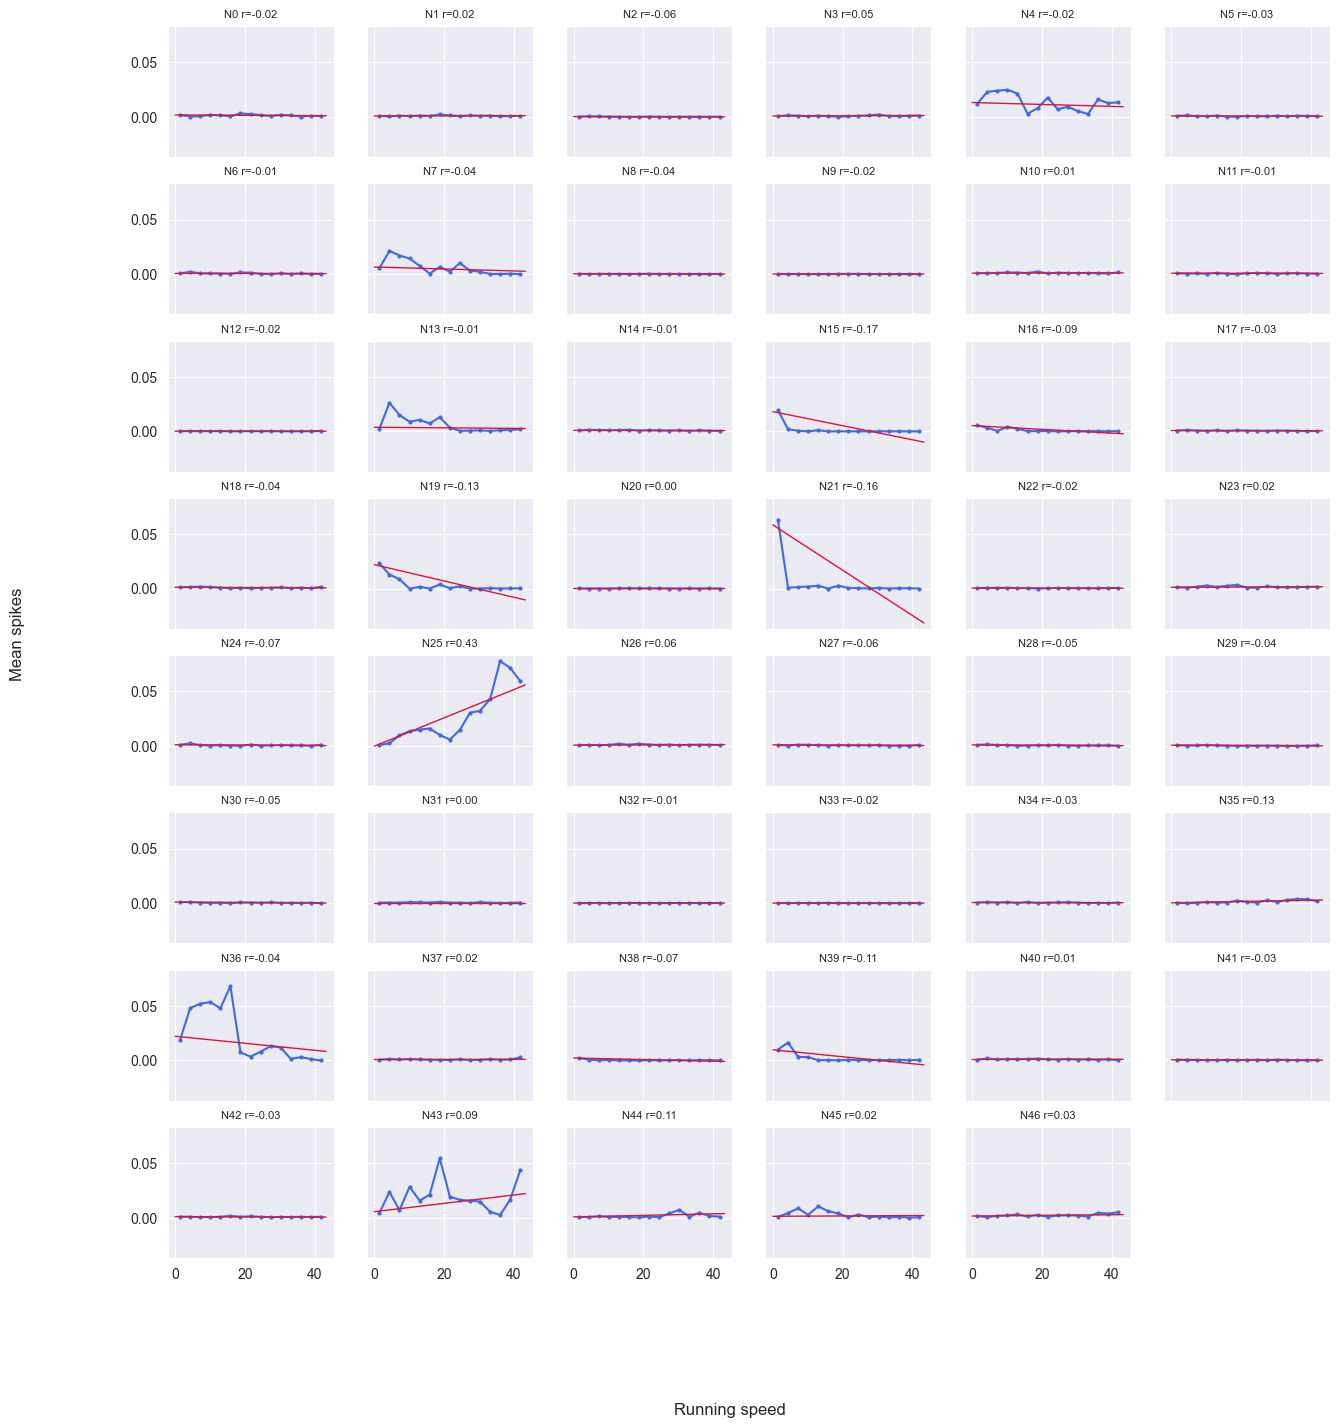

In [49]:
plot_running_modulation_all(binned_data, results, "B")

As expected, most of the neurons have flat curves, while others either increase their activation with increase speed (e.g. neuron 25), or fall back to almost zero firign rate which suggests that there might be an effect of surpression. Neuron 36 shows interesting behaviour in session B, where speed increase first increases neural activity but then it falls off again. This behaviour is partially reflected in session A. While this could be noise due to the small dataset, this might also be reflecting onset behaviour, as a mouse first increases the speed to reach higher speed levels.

To visualy examine the regression result and the speed modulation for the strongest influenced neuron (25) further, we can plot it with datapoints included.

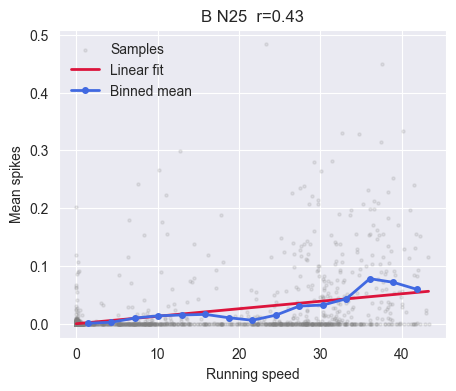

In [50]:
plot_running_modulation_neuron(binned_data, results, "B", 25)

As a sanity check, if the correlations stay stable across the sessions, we can plot this. (Note, session C data is sparse)

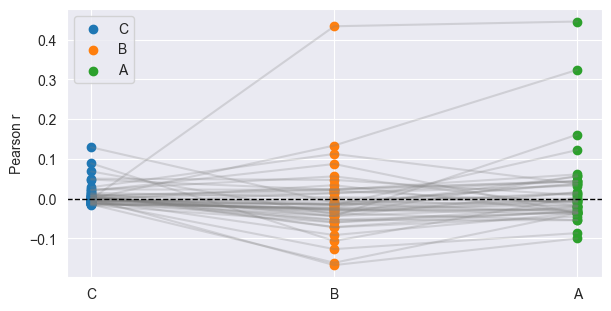

In [51]:
plot_running_correlation_sessions(results)

While there are differences between sessions, the direction and magnitude seem to be mostly consistent.

## Running Onset Modulation

#### Compute Running Onset - Spike Correlations
Similar to the above analysis, examining the onset also requires extraction of the relevant data and evaluating it ststistically.
This analysis requires three main steps:
1) Identifying running onsets, which means identifying sufficiently long below-threshold still phases followed by sufficiently long above-threshold running phases.
2) Extracting windows around the onsets
3) Applying statistical methods to identify possible modulators effects of running. For this, we compute the mean diff between the phase before onset and the phase after onset and test this via a sign-flip permutation test.

The method 'perform_onset_modulation_analysis' performs all three steps for each neuron of each session.

### Compute Onset Modulation

In [52]:
onset_results, onset_data = perform_onset_modulation_analysis(data)
for name, df in onset_results.items():
    print(name, "events:", df.n_events.iloc[0], "neurons:", len(df))

C events: 7 neurons: 47
B events: 22 neurons: 47
A events: 41 neurons: 47


The small number of occurrences limits the interpretation, especially for session C.

Some neurons reached significance in the permutation test:

In [53]:
for name, df in onset_results.items():
    sig = df[(df.p < 0.05) & (df.delta > 0)]
    print(name)
    print(sig[["neuron", "delta", "p"]])

C
Empty DataFrame
Columns: [neuron, delta, p]
Index: []
B
    neuron     delta         p
0        0  0.001790  0.000100
6        6  0.000587  0.046095
14      14  0.000904  0.002200
23      23  0.003127  0.000100
26      26  0.000899  0.006299
36      36  0.047700  0.000300
40      40  0.000834  0.015798
45      45  0.005579  0.011499
A
    neuron     delta         p
0        0  0.002012  0.000600
6        6  0.000428  0.004900
16      16  0.012515  0.002000
23      23  0.000888  0.002400
36      36  0.038015  0.022098


The most significant neuron in both sessions A and B is neuron 36. Remarkably, this is the neuron which showed a running speed modulation curve in the analysis above, that could be related to onset behaviour. Neuron 36 is also the only neuron that consistently shows a (strong) positive effect

To further assess onset modulation in general population (no effect) and specifically neuron 36 we inspect the results visually in the next section

### Onset Result Plots


Analogous to the correlation histogram above, we can look at the distribution of mean diffs per neuron here.


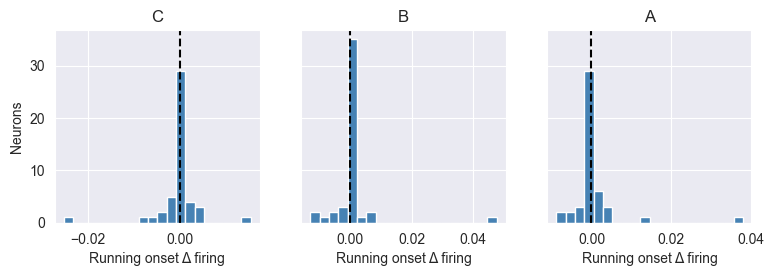

In [54]:
plot_onset_delta(onset_results)


While almost every neuron shows no effect, there are outliers, most notably the right-most outlier in the plots A and B which corresponds to neuron 36. To inspect the mean onset curves for the population and neuron 36, they are plotted below.


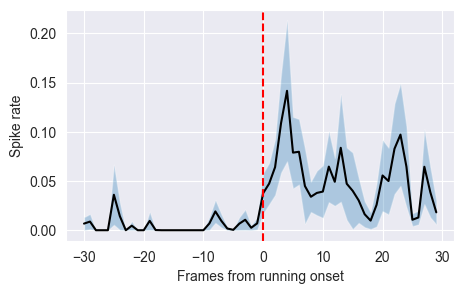

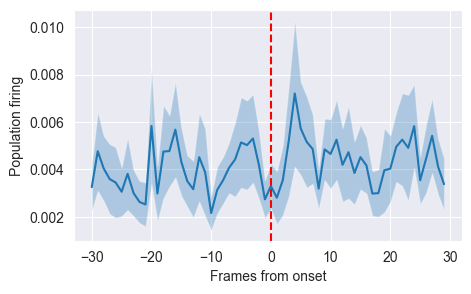

In [55]:
plot_onset_neuron(onset_data, "B", 36)
plot_population_onset(onset_data, "B")

While in the population curve no obvious effect is visible, neuron 36's activity seems to "jump" at onset time.

To give another overview of neural activity at onset time, there is a heatmap below, sorted by activity. Neuron 36 is the upmost neuron.

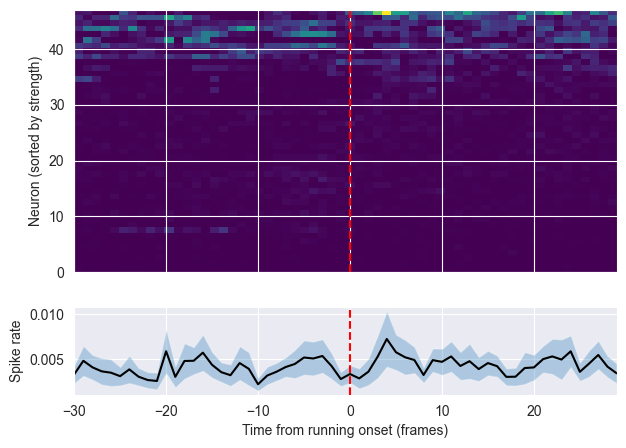

In [56]:
plot_onset_population(
    onset_data,
    "B"
)

## Intermediate Result

Given the limited data, the results of correlational and onset analysis have to be interpreted carefully. However, the analysis suggests that there might be some trends.
1) The average neuron and the majority of neurons seems not to be influenced by running onset or running speed.
2) Some neurons activity might be correlated to running speed (most notably here: neuron 25)
3) Some might be correlated with onsets (most notably here: neuron 36).
4) Some might be modulated slightly positively or negatively by running (correlations of up to -0.3) which could indicate sensory gating for some neurons and activity increase in others
5) Neuron response behaviour in relation to movement is very heterogeneous and probably very individual for single neurons

To also take stimulus presentation phases into the analysis, we also tried two other approaches: we investigsted the change in tuning during running phases and tried to capture the running speed as latent state in a GFPA model.

# Tuning analysis overview

In this section, we seek to assess how neurons are tuned to different grating orientation and directions.


We fit modified von Mises models to the spike counts:

$$
f(\theta) = \exp\!\left(\alpha + \kappa \bigl(\cos(2(\theta-\phi))-1\bigr)+ \nu \bigl(\cos(\theta-\phi)-1\bigr)\right)
$$

where $\theta$ represents stimulus orientation ($0^\circ$--$360^\circ$ for drifting gratings and $0^\circ$--$150^\circ$ for static gratings), $\phi$ the preferred orientation, $\alpha$ the baseline firing rate, and $\kappa$ and $\nu$ the components encoding orientation and direction selectivity.

To assess significant tuning, we use permutation tests. For each neuron, the power of the first and second Fourier component of the fitted tuning curve is compared against shuffled data representing uniform tuning. (1: direction tuning, 2: orientation tuning). The fraction of permutations yielding a more extreme value than the observed data provides the p-value for direction and orientation selectivity.

For each neuron, this analysis was performed separately for spike counts collected during stillness ($\leq 5$ cm/s) and running ($>5$ cm/s).


## 1. Drifting gratings


### 1.1 Without movement


In [57]:
# we look at direction tuning (first fourier component, use ground frequency)
PSI = 1

In [58]:
fitted_params = fit_tuning_curves(
    data,
    session="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=0 # still
)

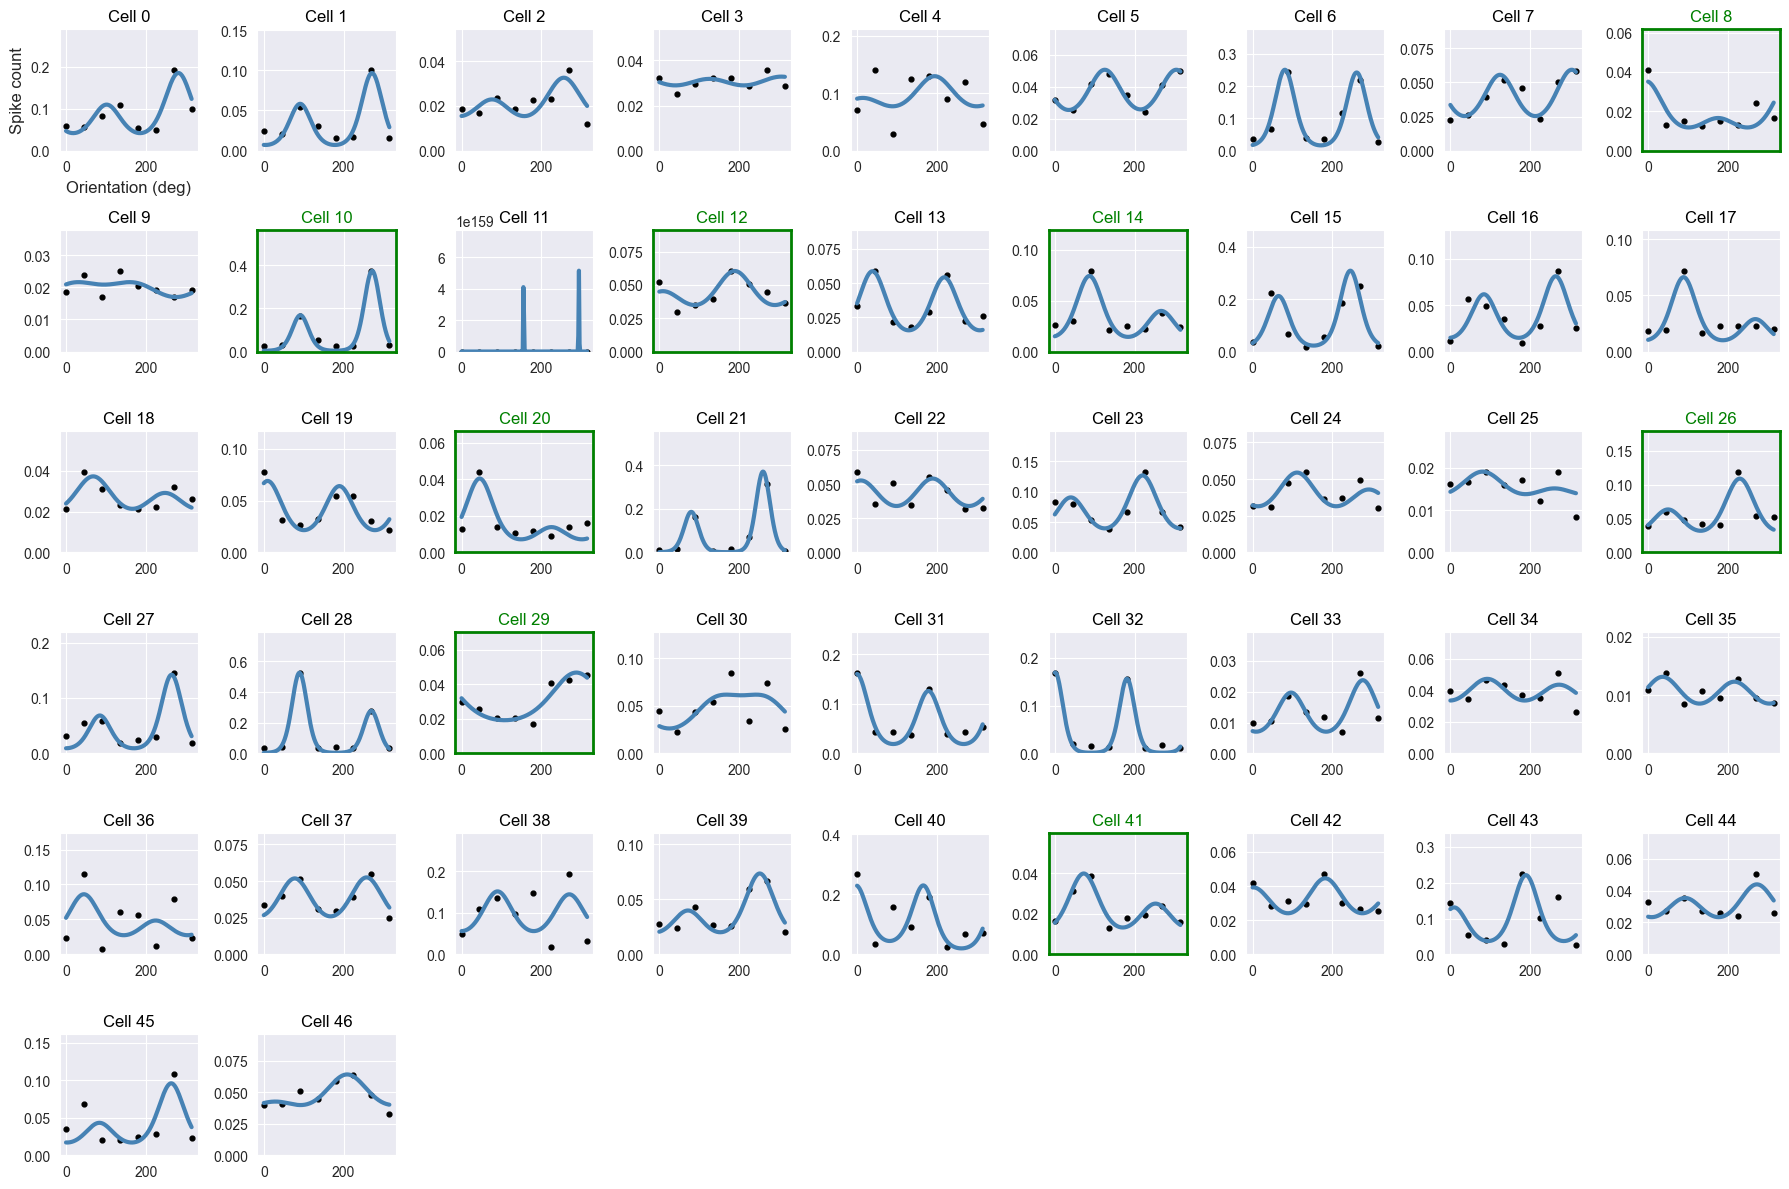

In [59]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=9,
    alpha=0.05,
    psi=PSI,
    only_significant=False,
)
plt.show()

### 1.1 With Movement


In [60]:
fitted_params = fit_tuning_curves(
    data,
    session="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=1 # running
)

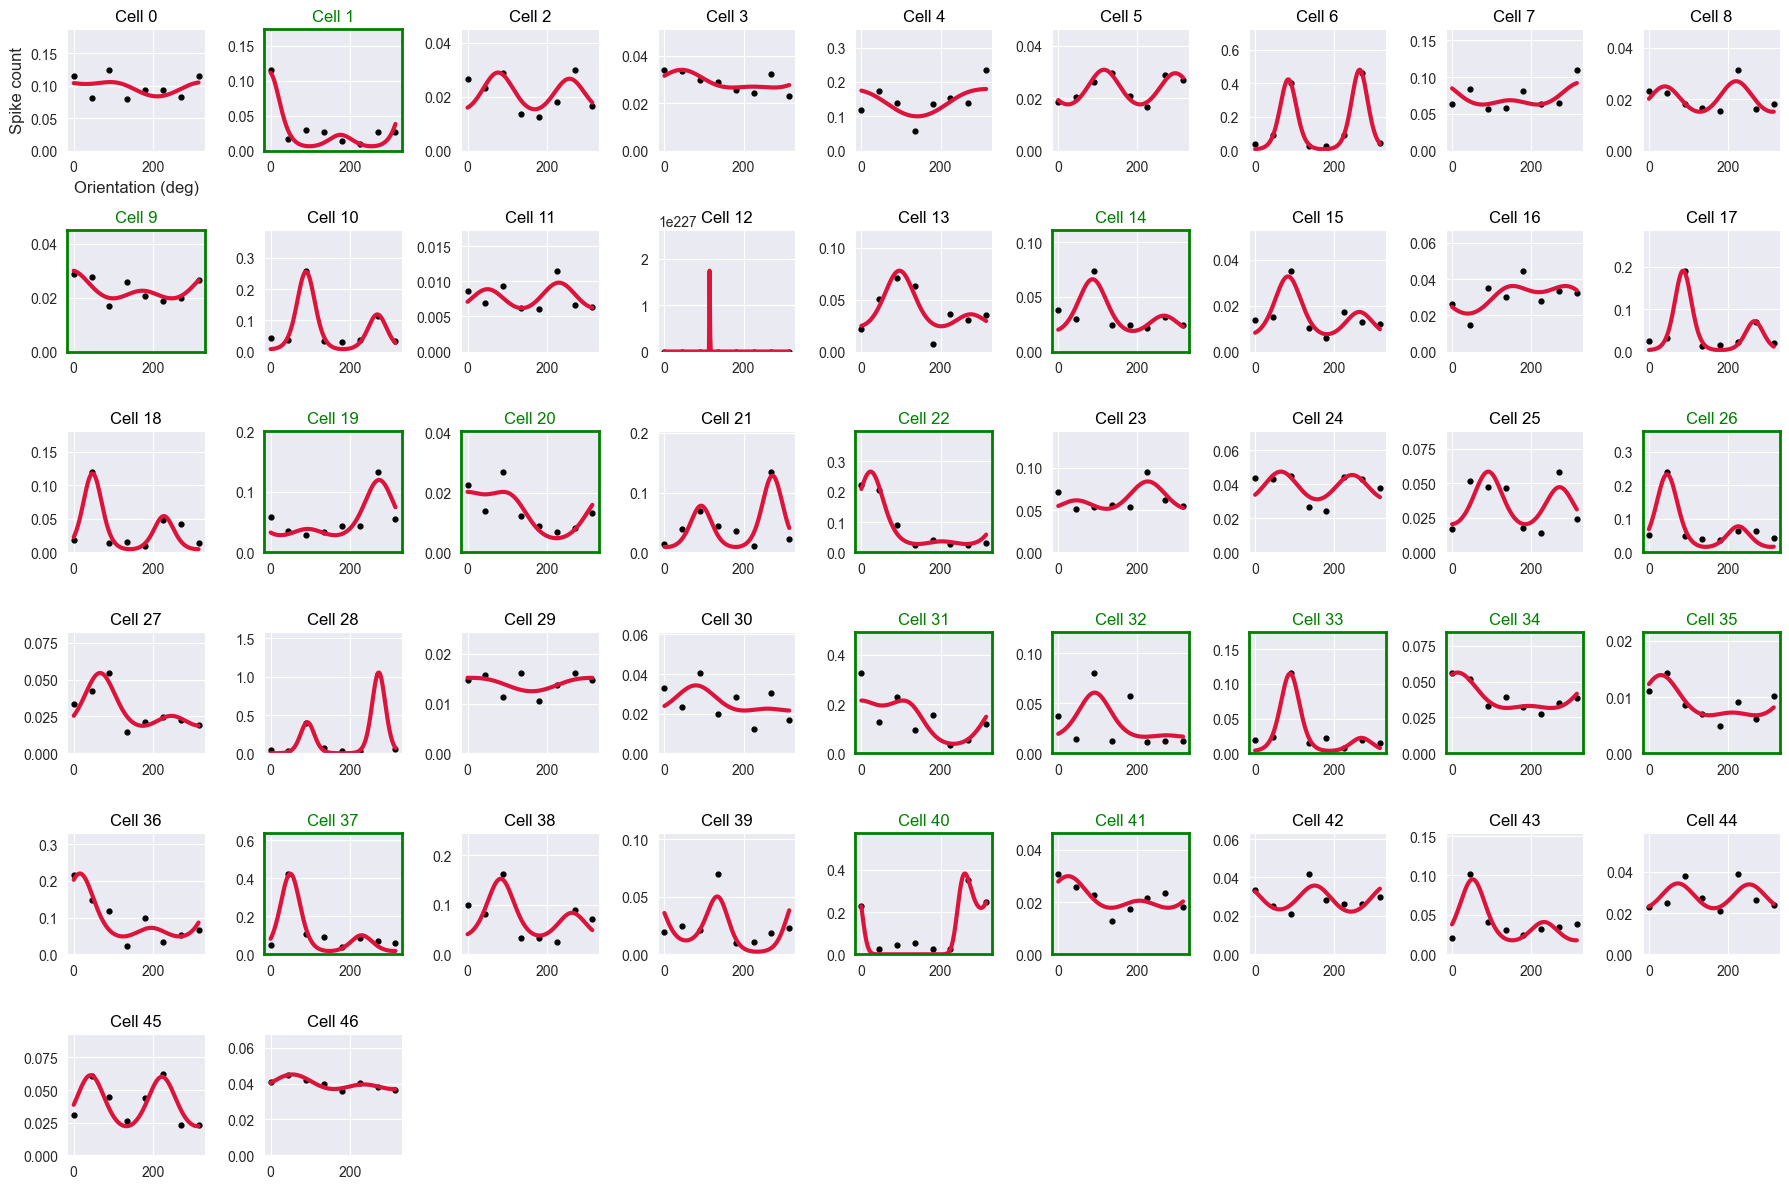

In [61]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=9,
    alpha=0.05,
    psi=PSI,
    only_significant=False
)
plt.show()

For both locomotion phases, different neuron populations showed significant direction tuning to moving grating orientations. Even neurons that were significant in both phases (e.g., neuron 24) exhibited shifts in their tuning behavior.

## 2. Static gratings


### 2.1 Without movement


In [62]:
# we look at orientation tuning (second fourier component, use second harmonic)
PSI = 2

In [63]:
fitted_params = fit_tuning_curves(
    data,
    session="B",
    stimulus="static_gratings",
    parameter="orientation",
    speed_phase=0 # still
)

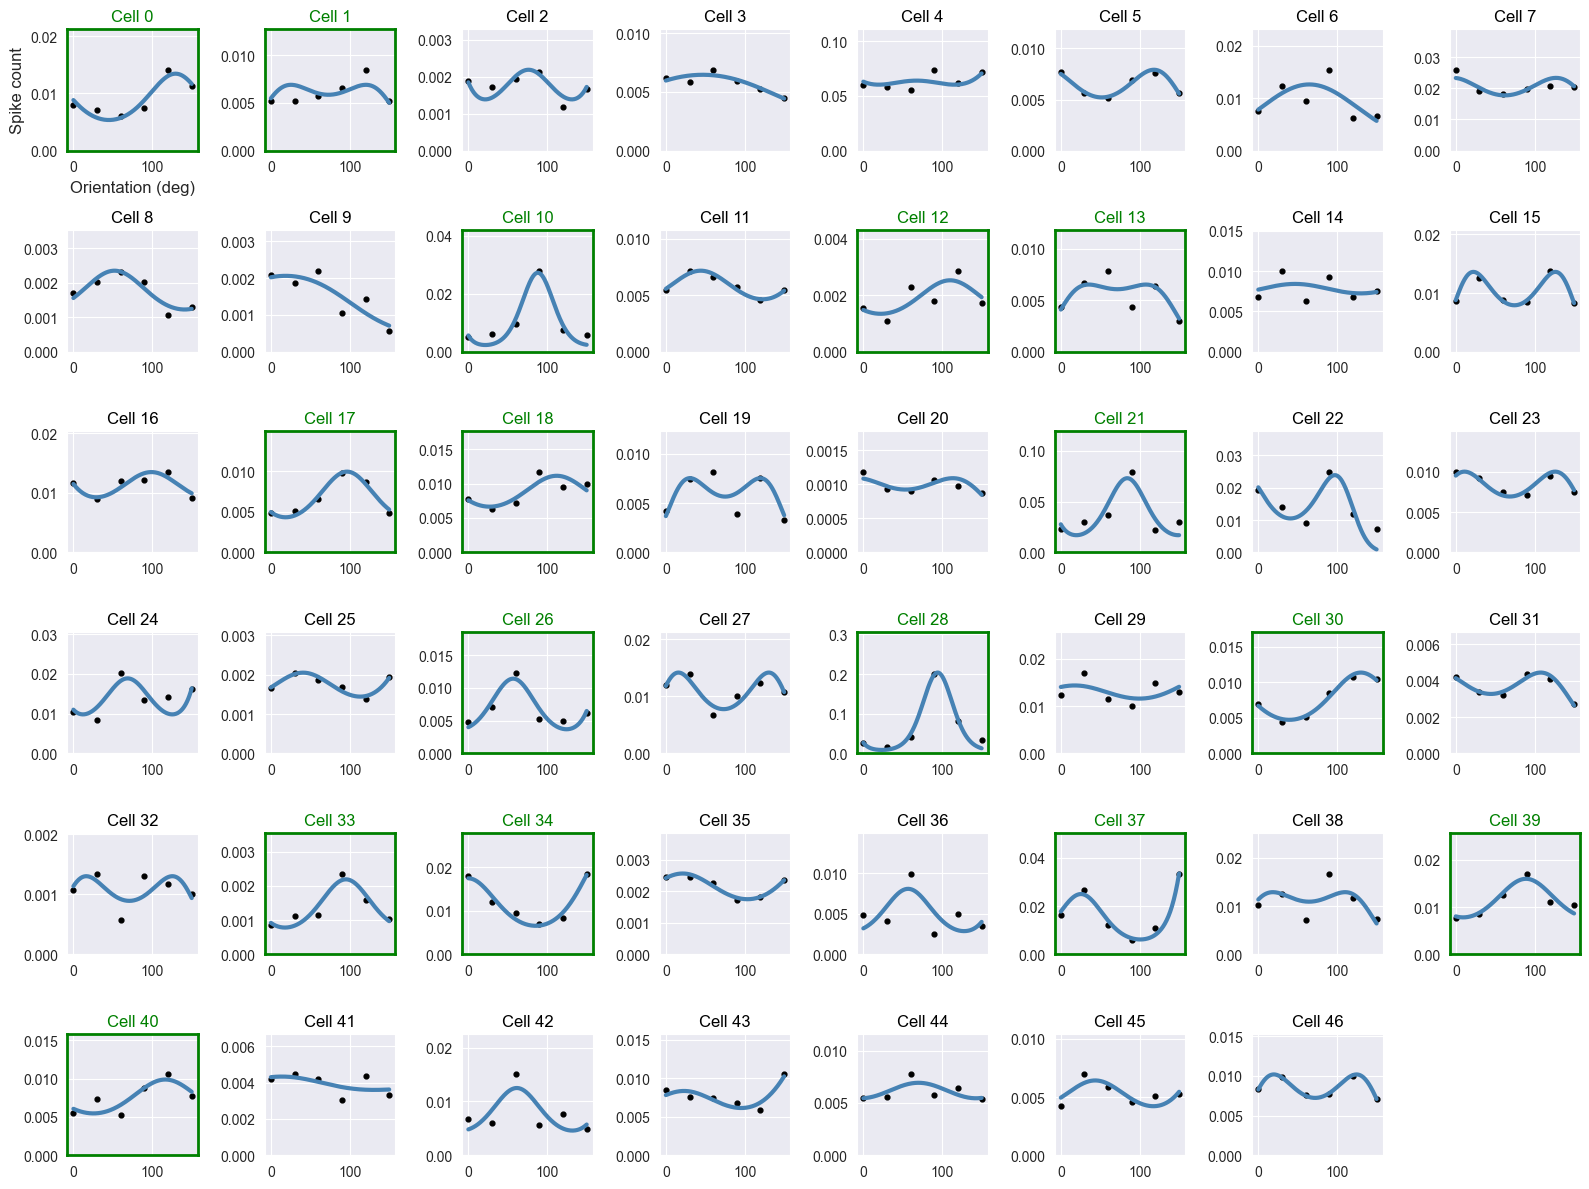

In [64]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=8,
    alpha=0.05,
    psi=PSI,
    only_significant=False
)
plt.show()

### 2.2 With movement

In [65]:
fitted_params = fit_tuning_curves(
    data,
    session="B",
    stimulus="static_gratings",
    parameter="orientation",
    speed_phase=1 # running
)

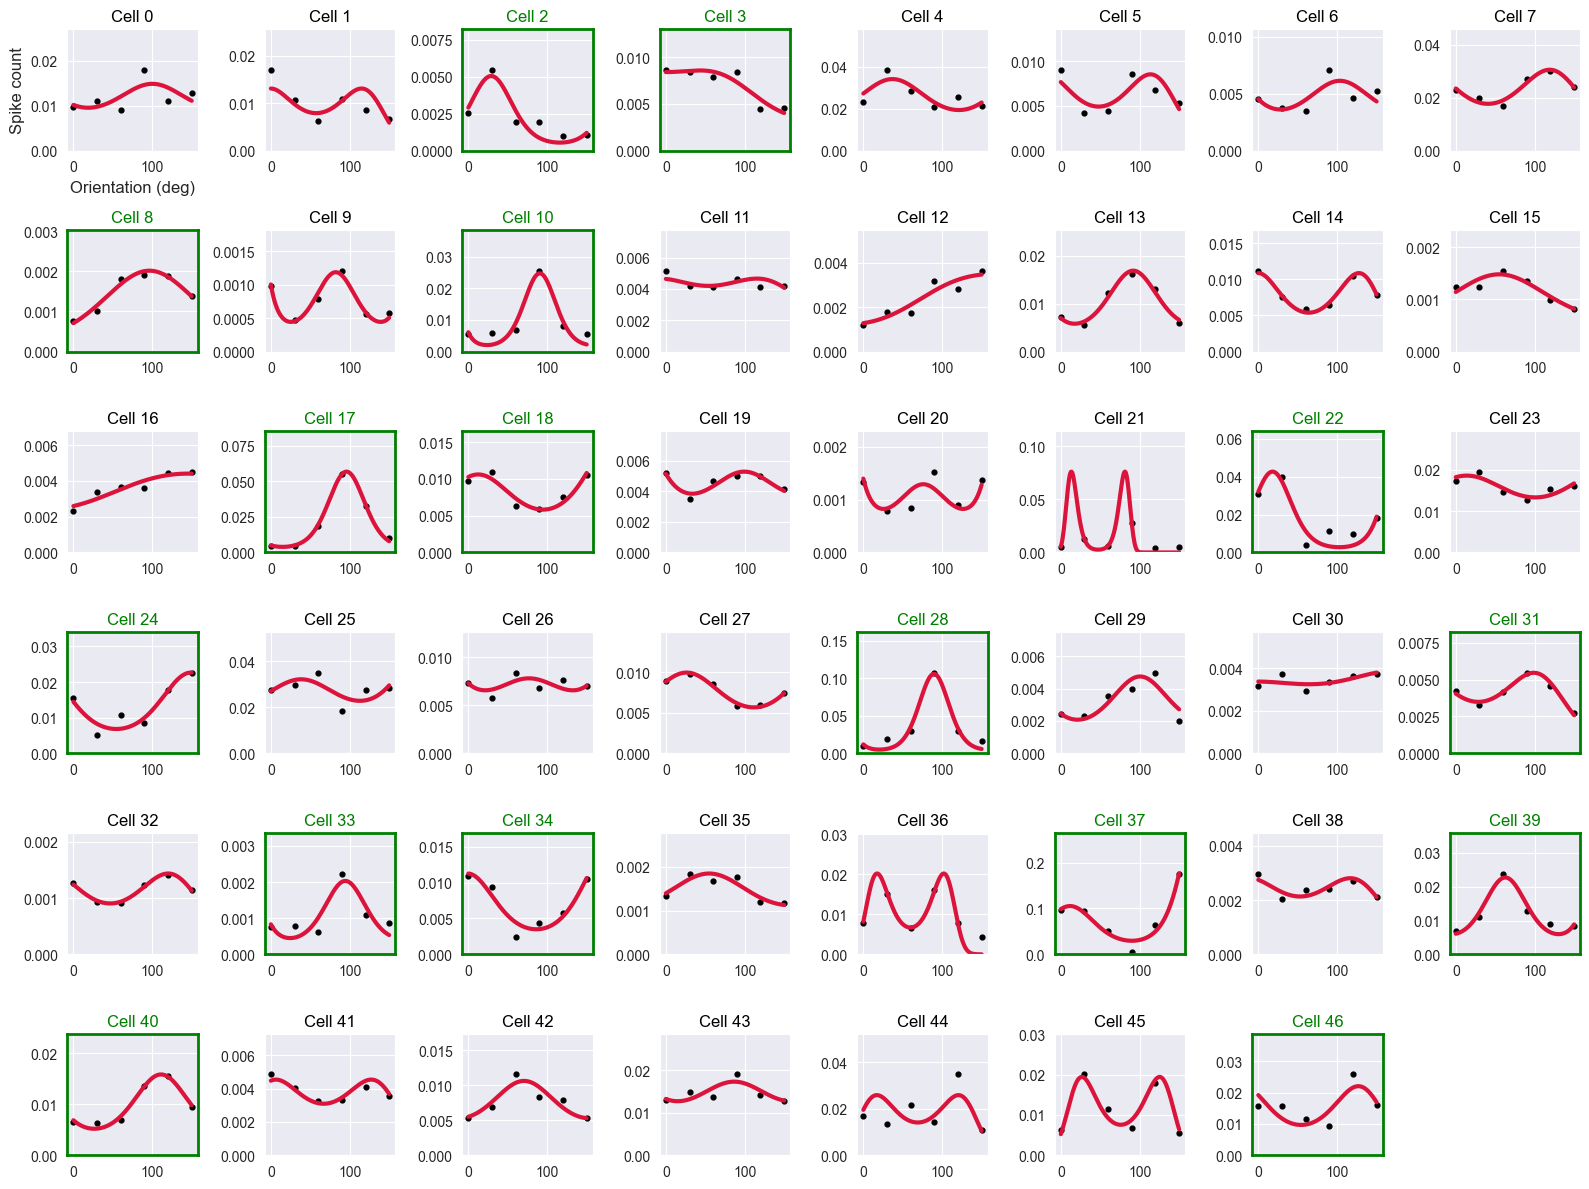

In [66]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=8,
    alpha=0.05,
    psi=PSI,
    only_significant=False,
)
plt.show()

We see that also when testing on orientation tuning with static gratings, there are differences in tuning behavior for different neurons.

## Intermediate Result

We found neurons tuned to different grating orientations and directions. Furthermore, distinct locomotion states recruited different tuned neuron populations, suggesting a potential population-level effect of locomotion during stimulus presentation.

However, these conclusions should be interpreted cautiously. Due to the limited amount of data, apparent changes in tuning may also arise from sampling variability, intrinsic neural variability, or measurement noise.

GPFA can provide a more thorough analysis of population-level neural variability and its relationship to running dynamics:

# GPFA analysis

## Preliminaries

For this section,  we use the same github repo as in exercise 6, the implementation of the EM algorithm to fit the poisson-gpfa:

Thus, to run this, you can clone `git clone https://github.com/berenslab/poisson-gpfa`.

Our directory structure looks like this:


```
├── data/
│   └── data_with_spikes_and_speed.txt
├── utils/
│   └── utils.py
|   └── poisson-gpfa/
├── notebooks
│   └── gpfa_analysis.ipynb
```
then you can import the related functions via:

```
import sys
sys.path.append('../poisson-gpfa/')
sys.path.append('../poisson-gpfa/funs')

import funs.util as util
import funs.engine as engine
```

Change the paths if you have a different directory structure.


In [ ]:
from pathlib import Path
import sys, os

notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.append(str(project_root))

# Add poisson-gpfa package
poisson_gpfa_path = project_root / "utils" / "poisson-gpfa"
sys.path.append(str(poisson_gpfa_path))
sys.path.append(str(poisson_gpfa_path / "funs"))

from utils.utils import *

import funs.util as util
import funs.engine as engine

### Motivation

- **Noise correlations** quantify the trial-to-trial covariability of responses between pairs of neurons when the same stimulus is presented repeatedly.
- They are important because they can influence the accuracy of neural population codes.
- Correlations can reflect meaningful **internal/top-down signals** that simultaneously modulate the activity of many neurons.

### Ecker et al. (2014)
- measured V1 neurons in **awake and anesthetized monkeys**.
- Most neurons were tuned to orientation, with qualitatively similar tuning between awake and anesthetized states.
- Under anesthesia:
  - responses were more variable (higher Fano factor),
  - average noise correlations increased compared to wakefulness.

### GPFA model
To identify shared population dynamics, they used **Gaussian Process Factor Analysis (GPFA)**, a latent variable model that describes neural activity as driven by a low-dimensional latent state:

$$
y_k(t)=f_k(s(t))+c_kx(t)+d_k+\nu_k(t)
$$

where:
- $y_k(t)$: firing rate of neuron $k$,
- $f_k(s(t))$: stimulus-dependent tuning component,
- $x(t)$: shared latent network state,
- $c_k$: loading describing how strongly neuron $k$ is influenced by the latent state,
- $d_k$: baseline firing rate,
- $\nu_k(t)$: independent observation noise (here poisson).

The latent state $x(t)$ evolves smoothly according to a Gaussian process with covariance:

$$
K_{ij}=\mathrm{Cov}[x(t_i),x(t_j)]
=
\exp\left(-\frac{(t_i-t_j)^2}{2\tau^2}\right)
$$

where $\tau$ determines the temporal smoothness of the latent dynamics.

### Our main idea

GPFA can be used to test if shared low-dimensional latent trajectories can explain trial-to-trial fluctuations underlying noise correlations in neural populations. It can further examine whether locomotion-related dynamics are reflected in latent trajectories.

To do this, we used the drifting grating dataset from session 1 due to its large sample size per trial.

Independent GPFA models were fitted for each stimulus condition (orientation, temporal frequency and blank sweep) and the locomotion state to reduce the bias of the stimulus type.

### Model fitting

- Extracted spike counts for each trial during a fixed stimulus period of $T=30$ non-overlapping bins (bin size: $33$ ms).
- Recorded running speed and running phase (still/running) for each trial.
- Fitted separate GPFA models for each stimulus condition and phases of black stimulus (blank sweeps)
- For each model:
  - Performed 10 EM iterations:
    - **E-step:** inferred the latent state trajectory $x(t)$ given the current parameters.
    - **M-step:** optimized the model parameters ($\tau$, $c_k$, and $d_k$) given the inferred latent state.
  - Used a single latent dimension ($x(t) \in \mathbb{R}^1$).
  - Initialized parameters using Poisson-PCA.
- We evaluated models on training sets only due to the limited amount of data available (after applying all our constraints, each model had only around $10$ trials; except for the blank sweep condition)

### Notebook structure
This section trains all GPFA models in a single loop and stores them in a dictionary indexed by stimulus and locomotion conditions (orientation, temporal frequency, and running phase).

Using the fitted parameters, we estimate the covariance structure for each model and identify conditions with the highest explained variance.

We then analyze the distribution of fitted parameters and finally compare the learned latent trajectories with the running speed trace.

Throughout this notebook, color blue denotes still phases (e.g phases where the mouse was not moving), and red denotes running phases (e.g phases where mouse was running with speed $\ge 2 cm/s$)

In [ ]:
stim_table = data["sessions"]["A"]["stim_tables"]["drifting_gratings"]
print(f" Unique orientation: {stim_table['orientation'].unique()}")
print(f" Unique temporal frequencies: {stim_table['temporal_frequency'].unique()}")
print(f" Unique blank sweeps: {stim_table['blank_sweep'].unique()}")

## 1. Train GPFA on each stimulus condition of drifting gratings

In [ ]:
# Some Hyperparameters
NR_TEST_TRIALS = 0
NR_EM_ITER = 10
BATCH_SIZE = 2
TEMPORAL_FREQUENCIES = [1, 2, 4, 8, 15]  # Hz
ORIENTATIONS = [0, 45, 90, 135, 180, 225, 270, 315]  # degrees
RUNNING_PHASES = [0, 1] # 0: still, 1: running
BLANK_SWEEPS = [0, 1]
NR_BINS = 30

In [ ]:
def fit_gpfa_condition(data, parameters, parameter_values, running_phase, key, fits):
    """Build a GPFADataset for one condition, fit GPFA if enough trials, and store it in fits."""
    dataset = GPFADataset(
        data=data,
        session_id="A",
        stimulus="drifting_gratings",
        parameters=parameters,
        parameter_values=parameter_values,
        minimum_nr_of_bins=NR_BINS,
        running_phase_value=running_phase,
    )

    if dataset.numTrials <= NR_TEST_TRIALS:
        return

    print(f"Fitting GPFA model for {key}...")
    xval = util.crossValidation(
        experiment=dataset,
        numTrainingTrials=dataset.numTrials - NR_TEST_TRIALS,
        numTestTrials=NR_TEST_TRIALS,
        maxXdim=1,  # for simplicity, we set latent dim to 1
        maxEMiter=NR_EM_ITER,
        batchSize=BATCH_SIZE,
        inferenceMethod="laplace",
        learningMethod="batch",
    )
    sys.stdout = open(os.devnull, "w")
    sys.stdout = sys.__stdout__

    train_set, test_set = util.splitTrainingTestDataset(
        dataset,
        numTrainingTrials=dataset.numTrials - NR_TEST_TRIALS,
        numTestTrials=NR_TEST_TRIALS,
    )

    fits[key] = (train_set, test_set, xval)


# First loop over all possible temporal frequencies and orientations,
fits = {}
for running_phase in RUNNING_PHASES:
    for orientation in ORIENTATIONS:
        for temporal_frequency in TEMPORAL_FREQUENCIES:
            key = (orientation, temporal_frequency, running_phase, False)
            fit_gpfa_condition(
                data, ["orientation", "temporal_frequency"], [orientation, temporal_frequency],
                running_phase, key, fits,
            )
    # Second loop over blank sweeps, if any
    print(f"Processing blank sweeps for running_phase={running_phase}")
    key = (None, None, running_phase, True)
    fit_gpfa_condition(data, ["blank_sweep"], [1], running_phase, key, fits)


In [ ]:
rows = []
for (orientation, temporal_frequency, running_phase, blank_sweep), (train_set, test_set, xval) in fits.items():
    rows.append({
        "Orientation": orientation,
        "Temporal Frequency": temporal_frequency,
        "Running Phase": "Running" if running_phase == 1 else "Still",
        "Blank Sweep": blank_sweep,
        "Train Trials": train_set.numTrials,
        "Test Trials": test_set.numTrials,
        "Trial Duration (ms)": round(train_set.trialDur, 1),
        "Bin Size (ms)": round(train_set.binSize, 1),
    })

fit_params = pd.DataFrame(rows)
fit_params

## 2. Noise correlations and their GPFA approximations

In [ ]:
NR_MODELS_TO_PLOT = 2

The approximate covariance for a given stimulus condition is computed using the analytical solution of the log-normal Cox process approximation:

$$
\mu = \exp\left(\frac{1}{2}\operatorname{diag}(CC^T)+d\right),
$$

$$
\mathrm{Cov} = \mu\otimes\mu^T \odot \left(\exp(CC^T)-\mathbb{I}\right)+ \mu\cdot\mathbb{I}.
$$

The fraction of explained variance (FVE) is then a fraction between the variance approximation and the data variance controlled for the independent poisson noise.

In [ ]:
def compute_cov_approx(fits):
    """Compute raw covariance, approximate covariance, and explained variance
    for each condition of the fit
    """

    raw_covs = {}
    approx_covs, approx_mus = {}, {}
    explained_vars = {}
    for key, (train_set, _, xval_drifting_gratings) in fits.items():

        # raw covariance from the training set
        all_Y = np.concatenate([trial["Y"] for trial in train_set.data], axis=1)  # shape (ydim, total_bins)
        raw_covs[key] = np.cov(all_Y)  # shape (ydim, ydim)

        # approximate covariance from the fitted GPFA model
        fit = xval_drifting_gratings.fits[0]
        approx_cov, approx_mu = cov_anal(fit)  # shape (ydim, ydim)
        approx_covs[key] = approx_cov
        approx_mus[key] = approx_mu

        # explained variance
        explained_vars[key] = var_explained(raw_covs[key], approx_covs[key], approx_mus[key])

    return raw_covs, approx_covs, approx_mus, explained_vars

In [ ]:
raw_covs, approx_covs, approx_mus, explained_variances = compute_cov_approx(fits)

We can compare the fraction of explained variances over all stimulus conditions between running and still phases.

In [ ]:
fig, ax = plot_explained_variance(
    explained_variances,
    figure_size=(4, 3)
)
plt.show()

We observe that the fraction of explained variance (FVE) is low for most conditions. This may be due to the sparse nature of the deconvolved calcium imaging output (here, from OASIS). Since the inferred spike trains contain relatively few non-zero bins, the GPFA model has limited shared structure available to capture, which caps how much variance it can explain.

Notably, blank-sweep trials tend to show higher explained variance, with a further, small increase during the running phases.

In [ ]:
# get the trial keys of the two conditions with the most explained variance for each running phase
top_trial_keys_per_phase = []
for running_phase in RUNNING_PHASES:
    # filter the explained_variances dictionary for the current running phase
    filtered_explained_variance = {k: v for k, v in explained_variances.items() if k[2] == running_phase}

    # sort the filtered dictionary by explained variance and get the top two keys
    top_trial_keys = [key for key, _ in sorted(filtered_explained_variance.items(), key=lambda item: item[1], reverse=True)]

    top_trial_keys_per_phase.append(top_trial_keys)

We can also plot the raw and approximated covariance matrices for some stimulus conditions (here for the ones with the most explained variances)

In [ ]:
# only plot covariances for the conditions with the most explained variance
# for each running phase
for running_phase in RUNNING_PHASES:
    trial_keys = top_trial_keys_per_phase[running_phase][:NR_MODELS_TO_PLOT]
    for trial_key in trial_keys:
        raw_cov = raw_covs[trial_key]
        approx_cov = approx_covs[trial_key]
        fig, axes = plot_covariances(raw_cov, approx_cov)
        plt.show()

This shows the pairwise covariance structure across all $47$ neurons for the best models in both locomotion states.

- The raw data show little shared covariance structure between neurons, leaving limited covariance patterns for the GPFA model to capture.
- The best-fitting models primarily reproduce the diagonal of the covariance matrix, corresponding to neuron-specific variance (baseline firing variability)

##  3. Parameter distributions

In [ ]:
NR_MODELS_TO_PLOT = 2


Useful to gain insights into the structure of variability induced by the network state variable.

Again plot this for the conditions that resulted in models with largest explained variance.

In [ ]:
fig, axes = plot_param_histograms(
    fits, param_name="C",
    bins=30,
    running_phase=0,
    trial_keys=top_trial_keys_per_phase[0][:NR_MODELS_TO_PLOT],
    figsize_per_cell=(3, 2))

plt.show()

fig, axes = plot_param_histograms(
    fits, param_name="C",
    bins=30,
    running_phase=1,
    trial_keys=top_trial_keys_per_phase[1][:NR_MODELS_TO_PLOT],
    figsize_per_cell=(3, 2))

plt.show()

- The weight distribution $c_k$ describes how strongly the latent state influences the firing rate of each neuron.
- If locomotion induces a shared latent modulation, neurons should show a consistent shift in their weights during the active phase of the latent state (e.g., running).
- However, across all stimulus conditions, the weights remained centered around zero with no clear difference between locomotion phases, suggesting limited  modulation by the learned latent state.

In [ ]:
fig, axes = plot_param_histograms(
    fits,
    param_name="d",
    bins=30,
    running_phase=0,
    trial_keys=top_trial_keys_per_phase[0][:NR_MODELS_TO_PLOT]
    )
plt.show()

fig, axes = plot_param_histograms(
    fits,
    param_name="d",
    bins=30,
    running_phase=1,
    trial_keys=top_trial_keys_per_phase[1][:NR_MODELS_TO_PLOT]
    )
plt.show()

The offset parameter $d_k$ represents the baseline firing rate of individual neurons.
- The distributions were similar across stimulus conditions and locomotion phases, with only a few outliers.
- Interestingly, one outlier corresponded to neuron 25, which was previously identified as the neuron most strongly correlated with running speed (see notebook correlations_and_onset.ipynb)

In [ ]:
fig, ax = plot_tau_histogram(
    fits,
    bins=30,
    figure_size=(5, 3)
)
plt.show()

The latent timescale  provides a further constraint on whether GPFA captures locomotion-related dynamics.
If the latent state reflects running speed fluctuations, its timescale should be comparable to that of the running signal.
The fitted timescales ranged from $0$  to $0.6$ s, largely independent of the locomotion phase.
These timescales only partially overlap with running speed dynamics (note: running frequencies were clipped at 5 Hz).


## 4. Compare latent to running traces

We now plot some traces of latent state variables and compare them to the running trajectory given in one example trial. We again plot this for the models with largest explained variance.

In [ ]:
NR_MODELS_TO_PLOT = 6

In [ ]:
fig, axes = plot_gpfa_latent_and_speed_grid(
    fits,
    trial_keys=top_trial_keys_per_phase[0][:NR_MODELS_TO_PLOT],
    running_phase=0,
    figsize_per_cell=(3.5, 2.5),
    trial_idx=2
)
plt.show()

fig, axes = plot_gpfa_latent_and_speed_grid(
    fits,
    trial_keys=top_trial_keys_per_phase[1][:NR_MODELS_TO_PLOT],
    running_phase=1,
    figsize_per_cell=(3.5, 2.5),
    trial_idx=2
)
plt.show()

The latent network state evolves smoothly over time and can be compared with the (smoothed) running speed trace.

During periods without movement, the running signal shows faster fluctuations than the latent trace.

However, in both cases, the running trace is not able to match with the latent trajectory in a consistent way. An exception may be the blank-sweep trials during running, where the latent trajectory becomes more variable and shows some qualitative alignment with changes in the running signal.


## Intermediate Result

Most models were unable to capture meaningful trial-to-trial noise correlations in the population activity and only reproduced the magnitude of the neuron-intrinsic firing rate baseline. This could be due to sparse spike counts and limited number of trials available for each stimulus condition and running state.

As a consequence, the inferred latent trajectories cannot be interpreted reliably nor be meaningfully compared to the running speed traces.

One exception might be the blank-sweep trials, where more trials per condition were available to train on. Here, the models explained more variance, and the latent trajectories showed some qualitative alignment with the running speed.

A natural next step would be to repeat the analysis using the larger raw dataset provided in https://allenswdb.github.io/physiology/ophys/visual-behavior/VB-Ophys.html.
